Dataset Link -> https://www.kaggle.com/datasets/nishantdeswal1810/smartphones

About Dataset
DESCRIPTION:
This dataset provides comprehensive information about various smartphone models, facilitating detailed analysis and comparison. It encompasses crucial attributes such as model name, price, rating, similarity index (sim), processor details, RAM capacity, battery specifications, display features, camera specifications, expandable memory card support, and operating system (OS) details.

Columns:

1.Model: The name or designation of the smartphone model.

2.Price: The retail price of the smartphone, typically in a specified currency.

3.Rating: The user or expert rating of the smartphone, providing an indication of its overall quality and user satisfaction.

4.Sim: The number of SIM cards supported by the smartphone.

5.Processor: Details about the processor or chipset used in the smartphone, including brand, model, and specifications.

6.RAM: The amount of random-access memory (RAM) available in the smartphone, measured in gigabytes (GB).

7.Battery: Information regarding the battery capacity and type, providing insight into the device's endurance and usage duration.

8.Display: Specifications related to the smartphone's display, such as size, resolution, technology (e.g., LCD, OLED), and any additional features (e.g., HDR support).

9.Camera: Details about the smartphone's camera setup, including megapixel count, lens specifications, and additional features like image stabilization or AI enhancements.

10.Card: Indicates whether the smartphone supports expandable memory cards, providing users with the option to increase storage capacity.

11.OS: The operating system installed on the smartphone, including the version number if applicable.

This dataset is valuable for various analyses, including:

1.Price-performance comparisons: Assessing the correlation between price and features like processor, RAM, and camera quality.

2.Market trend analysis: Identifying popular models based on ratings and sales data.

3.Feature preference analysis: Examining which features (e.g., battery capacity, camera quality) are most valued by consumers.

4.Brand comparison: Comparing specifications and performance across different smartphone brands.

5.Predictive modeling: Using historical data to predict future trends in smartphone design and consumer preferences.

The dataset is ideal for data scientists, researchers, and analysts interested in the smartphone industry, consumer behavior, and technology trends. It can be utilized for exploratory data analysis, machine learning modeling, and generating insights to inform business decisions within the mobile device market.

In [1084]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [1085]:
smt_df = pd.read_csv("https://raw.githubusercontent.com/subhajitmahapatra007/Mobile-Dataset-Scrapping-and-analysis/refs/heads/main/dataset/Smartphone_uncleaned.csv")

In [1086]:
smt_df

,model,prices,rating,sim,processor,ram,battery,display,camera,card,os
0,Motorola Edge 70 Fusion,"₹27,589",70.0,"Dual Sim, 5G, VoLTE, Vo5G, NFC, Wi-Fi","Snapdragon 7s Gen4, Octa Core, 2.7 GHz Processor","8 GB RAM, 128 GB inbuilt",7000 mAh Battery with 68W Fast Charging,"6.8 inches, 1272 x 2772 px, 144 Hz Display wit...",50 MP + 13 MP + Dedicated 3-in-1 light sensor ...,Android v16,No FM Radio
1,Xiaomi Redmi Note 17 Pro Max,"₹49,999",NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi, IR Blaster","Snapdragon 6 Gen5, Octa Core, 2.6 GHz Processor","8 GB RAM, 256 GB inbuilt",10000 mAh Battery with 100W Fast Charging,"6.83 inches, 1280 x 2772 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 32 MP Front Camera,Android v16,No FM Radio
2,Realme P3 5G,"₹15,999",61.0,"Dual Sim, 5G, VoLTE, NFC, Wi-Fi","Snapdragon 6 Gen4, Octa Core, 2.3 GHz Processor","6 GB RAM, 128 GB inbuilt",6000 mAh Battery with 45W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 2 MP Dual Rear & 16 MP Front Camera,Android v15,No FM Radio
3,Apple iPhone 18 Pro,"₹1,64,900",NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Apple A20 Pro, Hexa Core Processor","12 GB RAM, 256 GB inbuilt",4056 mAh Battery with Fast Charging,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP + 48 MP Triple Rear & 18 MP Fron...,Memory Card Not Supported,iOS v27
4,Realme P3 Pro 5G (12GB RAM +256GB),"₹23,999",66.0,"Dual Sim, 5G, VoLTE, Wi-Fi","Snapdragon 7s Gen3, Octa Core, 2.5 GHz Processor","12 GB RAM, 256 GB inbuilt",6000 mAh Battery with 80W Fast Charging,"6.83 inches, 1272 x 2800 px, 120 Hz Display wi...",50 MP + 2 MP Dual Rear & 16 MP Front Camera,Android v15,No FM Radio
5,Xiaomi Redmi Note 17 Pro,"₹36,999",71.0,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi, IR Blaster","Snapdragon 6s Gen4, Octa Core, 2.4 GHz Processor","6 GB RAM, 128 GB inbuilt",9000 mAh Battery with 67W Fast Charging,"6.83 inches, 1280 x 2772 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 16 MP Front Camera,Android v16,No FM Radio
6,Apple iPhone 17,"₹82,900",76.0,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Apple A19, Hexa Core Processor","8 GB RAM, 256 GB inbuilt",3692 mAh Battery with Fast Charging,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP Dual Rear & 18 MP Front Camera,Memory Card Not Supported,iOS v26
7,Xiaomi Redmi 17 5G,"₹23,999",61.0,"Dual Sim, 5G, VoLTE, NFC, Wi-Fi, IR Blaster","Snapdragon 4 Gen5, Octa Core, 2.4 GHz Processor","6 GB RAM, 128 GB inbuilt",7900 mAh Battery with 45W Fast Charging,"6.9 inches, 720 x 1600 px, 120 Hz Display with...",50 MP + Auxiliary lens Dual Rear & 8 MP Front ...,"Memory Card (Hybrid), upto 2 TB",Android v16
8,OnePlus Nord 5 5G,"₹31,999",75.0,"Dual Sim, 5G, VoLTE, NFC, Wi-Fi, IR Blaster","Snapdragon 8s Gen3, Octa Core, 3 GHz Processor","8 GB RAM, 256 GB inbuilt",6800 mAh Battery with 80W Fast Charging,"6.83 inches, 1272 x 2800 px, 144 Hz Display wi...",50 MP + 8 MP Dual Rear & 50 MP Front Camera,Android v15,No FM Radio
9,Vivo T5 5G,"₹34,999",71.0,"Dual Sim, 5G, VoLTE, Wi-Fi, IR Blaster","Dimensity 7500 Turbo, Octa Core, 2.6 GHz Proce...","6 GB RAM, 128 GB inbuilt",7050 mAh Battery with 44W Fast Charging,"6.83 inches, 1260 x 2800 px, 144 Hz Display wi...",50 MP + 8 MP Dual Rear & 32 MP Front Camera,Memory Card Not Supported,Android v16


## Data Assesssing

In [1087]:
smt_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   model      1020 non-null   object 
 1   prices     1020 non-null   object 
 2   rating     639 non-null    float64
 3   sim        1020 non-null   object 
 4   processor  1020 non-null   object 
 5   ram        1020 non-null   object 
 6   battery    1020 non-null   object 
 7   display    1020 non-null   object 
 8   camera     1014 non-null   object 
 9   card       999 non-null    object 
 10  os         958 non-null    object 
dtypes: float64(1), object(10)
memory usage: 87.8+ KB


In [1088]:
smt_df.duplicated().sum()

np.int64(0)

In [1089]:
smt_df.head()

,model,prices,rating,sim,processor,ram,battery,display,camera,card,os
0,Motorola Edge 70 Fusion,"₹27,589",70.0,"Dual Sim, 5G, VoLTE, Vo5G, NFC, Wi-Fi","Snapdragon 7s Gen4, Octa Core, 2.7 GHz Processor","8 GB RAM, 128 GB inbuilt",7000 mAh Battery with 68W Fast Charging,"6.8 inches, 1272 x 2772 px, 144 Hz Display wit...",50 MP + 13 MP + Dedicated 3-in-1 light sensor ...,Android v16,No FM Radio
1,Xiaomi Redmi Note 17 Pro Max,"₹49,999",NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi, IR Blaster","Snapdragon 6 Gen5, Octa Core, 2.6 GHz Processor","8 GB RAM, 256 GB inbuilt",10000 mAh Battery with 100W Fast Charging,"6.83 inches, 1280 x 2772 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 32 MP Front Camera,Android v16,No FM Radio
2,Realme P3 5G,"₹15,999",61.0,"Dual Sim, 5G, VoLTE, NFC, Wi-Fi","Snapdragon 6 Gen4, Octa Core, 2.3 GHz Processor","6 GB RAM, 128 GB inbuilt",6000 mAh Battery with 45W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 2 MP Dual Rear & 16 MP Front Camera,Android v15,No FM Radio
3,Apple iPhone 18 Pro,"₹1,64,900",NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Apple A20 Pro, Hexa Core Processor","12 GB RAM, 256 GB inbuilt",4056 mAh Battery with Fast Charging,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP + 48 MP Triple Rear & 18 MP Fron...,Memory Card Not Supported,iOS v27
4,Realme P3 Pro 5G (12GB RAM +256GB),"₹23,999",66.0,"Dual Sim, 5G, VoLTE, Wi-Fi","Snapdragon 7s Gen3, Octa Core, 2.5 GHz Processor","12 GB RAM, 256 GB inbuilt",6000 mAh Battery with 80W Fast Charging,"6.83 inches, 1272 x 2800 px, 120 Hz Display wi...",50 MP + 2 MP Dual Rear & 16 MP Front Camera,Android v15,No FM Radio


In [1090]:
pd.set_option('display.max_rows', None)
pd.set_option("display.max_columns", None)

## Data Cleaning

In [1091]:
df = smt_df.copy()

In [1092]:
df.head()

,model,prices,rating,sim,processor,ram,battery,display,camera,card,os
0,Motorola Edge 70 Fusion,"₹27,589",70.0,"Dual Sim, 5G, VoLTE, Vo5G, NFC, Wi-Fi","Snapdragon 7s Gen4, Octa Core, 2.7 GHz Processor","8 GB RAM, 128 GB inbuilt",7000 mAh Battery with 68W Fast Charging,"6.8 inches, 1272 x 2772 px, 144 Hz Display wit...",50 MP + 13 MP + Dedicated 3-in-1 light sensor ...,Android v16,No FM Radio
1,Xiaomi Redmi Note 17 Pro Max,"₹49,999",NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi, IR Blaster","Snapdragon 6 Gen5, Octa Core, 2.6 GHz Processor","8 GB RAM, 256 GB inbuilt",10000 mAh Battery with 100W Fast Charging,"6.83 inches, 1280 x 2772 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 32 MP Front Camera,Android v16,No FM Radio
2,Realme P3 5G,"₹15,999",61.0,"Dual Sim, 5G, VoLTE, NFC, Wi-Fi","Snapdragon 6 Gen4, Octa Core, 2.3 GHz Processor","6 GB RAM, 128 GB inbuilt",6000 mAh Battery with 45W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 2 MP Dual Rear & 16 MP Front Camera,Android v15,No FM Radio
3,Apple iPhone 18 Pro,"₹1,64,900",NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Apple A20 Pro, Hexa Core Processor","12 GB RAM, 256 GB inbuilt",4056 mAh Battery with Fast Charging,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP + 48 MP Triple Rear & 18 MP Fron...,Memory Card Not Supported,iOS v27
4,Realme P3 Pro 5G (12GB RAM +256GB),"₹23,999",66.0,"Dual Sim, 5G, VoLTE, Wi-Fi","Snapdragon 7s Gen3, Octa Core, 2.5 GHz Processor","12 GB RAM, 256 GB inbuilt",6000 mAh Battery with 80W Fast Charging,"6.83 inches, 1272 x 2800 px, 120 Hz Display wi...",50 MP + 2 MP Dual Rear & 16 MP Front Camera,Android v15,No FM Radio


In [1093]:
df['prices'] = df['prices'].str.replace("₹",'').str.replace(',','').astype('int')

In [1094]:
df.shape

(1020, 11)

In [1095]:
df.head()

,model,prices,rating,sim,processor,ram,battery,display,camera,card,os
0,Motorola Edge 70 Fusion,27589,70.0,"Dual Sim, 5G, VoLTE, Vo5G, NFC, Wi-Fi","Snapdragon 7s Gen4, Octa Core, 2.7 GHz Processor","8 GB RAM, 128 GB inbuilt",7000 mAh Battery with 68W Fast Charging,"6.8 inches, 1272 x 2772 px, 144 Hz Display wit...",50 MP + 13 MP + Dedicated 3-in-1 light sensor ...,Android v16,No FM Radio
1,Xiaomi Redmi Note 17 Pro Max,49999,NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi, IR Blaster","Snapdragon 6 Gen5, Octa Core, 2.6 GHz Processor","8 GB RAM, 256 GB inbuilt",10000 mAh Battery with 100W Fast Charging,"6.83 inches, 1280 x 2772 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 32 MP Front Camera,Android v16,No FM Radio
2,Realme P3 5G,15999,61.0,"Dual Sim, 5G, VoLTE, NFC, Wi-Fi","Snapdragon 6 Gen4, Octa Core, 2.3 GHz Processor","6 GB RAM, 128 GB inbuilt",6000 mAh Battery with 45W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 2 MP Dual Rear & 16 MP Front Camera,Android v15,No FM Radio
3,Apple iPhone 18 Pro,164900,NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Apple A20 Pro, Hexa Core Processor","12 GB RAM, 256 GB inbuilt",4056 mAh Battery with Fast Charging,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP + 48 MP Triple Rear & 18 MP Fron...,Memory Card Not Supported,iOS v27
4,Realme P3 Pro 5G (12GB RAM +256GB),23999,66.0,"Dual Sim, 5G, VoLTE, Wi-Fi","Snapdragon 7s Gen3, Octa Core, 2.5 GHz Processor","12 GB RAM, 256 GB inbuilt",6000 mAh Battery with 80W Fast Charging,"6.83 inches, 1272 x 2800 px, 120 Hz Display wi...",50 MP + 2 MP Dual Rear & 16 MP Front Camera,Android v15,No FM Radio


## **Solving Validation Issues**

In [1096]:
# problematic_rows
sim = set((651,655,859,946,948))

processor = set((203, 307, 371, 390, 399, 433, 463, 483, 516, 535,540, 564, 581, 625, 641, 651, 655, 662, 667, 710,714, 718, 760, 762, 766, 803, 805, 814, 829,
    841,844, 852, 859, 867, 871, 872, 874, 877, 879, 881, 893, 912, 927, 933, 934, 940, 941, 944, 946, 948,953, 954, 960, 961, 962, 966, 968, 972, 974, 987,
    1001, 1008, 1009, 1010, 1011, 1018))

ram = set((307, 371, 390, 399, 463, 483, 516, 540, 564, 581,625, 651, 655, 662, 667, 710, 760, 762, 766, 803,829, 841, 844, 852, 859, 867, 874, 877, 879, 893,
    912, 927, 933, 934, 940, 941, 944, 946, 948, 953,954, 961, 962, 966, 974, 987, 1008, 1009, 1010))

battery = set((307, 371, 390, 399, 463, 483, 516, 540, 564, 581,625, 651, 655, 662, 667, 710, 760, 762, 766, 803,805, 829, 841, 844, 852, 859, 867, 874, 877, 879,
    893, 912, 927, 933, 934, 940, 941, 944, 946, 948, 953, 954, 961, 962, 966, 974, 987, 1008, 1009, 1010,1018))

display = set((307, 371, 390, 399, 463, 483, 516, 540, 564, 581, 625, 651, 655, 662, 667, 710, 760, 762, 766, 803,805, 829, 841, 852, 859, 867, 874, 877, 879, 893,
    912, 927, 933, 934, 940, 941, 944, 946, 948, 953,954, 961, 962, 966, 974, 987, 1008, 1009, 1010, 1018))

camera = set((24, 76, 155,171, 192, 194, 307, 354, 371, 389, 390, 399, 400, 419, 435, 445, 463, 483, 515, 516, 518, 540, 558, 564, 567, 568, 581, 593,
                      607, 609, 616, 619, 623, 625, 630, 640, 646,651,654,655,662,667,672,679,710,760,762,766,795,799,803,805,822,829,841,842,844,847,852,859,
                      867, 872, 874, 877, 879, 882, 885, 893, 912, 927, 933, 934, 940, 941, 944, 945, 946, 948, 953, 954,956, 958, 961, 962,
                      966, 968, 971, 974, 987, 999,1008, 1009, 1010, 1013)
)

In [1097]:
df = df.reset_index()
df['index'] = df['index'] + 2
df.head()

,index,model,prices,rating,sim,processor,ram,battery,display,camera,card,os
0,2,Motorola Edge 70 Fusion,27589,70.0,"Dual Sim, 5G, VoLTE, Vo5G, NFC, Wi-Fi","Snapdragon 7s Gen4, Octa Core, 2.7 GHz Processor","8 GB RAM, 128 GB inbuilt",7000 mAh Battery with 68W Fast Charging,"6.8 inches, 1272 x 2772 px, 144 Hz Display wit...",50 MP + 13 MP + Dedicated 3-in-1 light sensor ...,Android v16,No FM Radio
1,3,Xiaomi Redmi Note 17 Pro Max,49999,NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi, IR Blaster","Snapdragon 6 Gen5, Octa Core, 2.6 GHz Processor","8 GB RAM, 256 GB inbuilt",10000 mAh Battery with 100W Fast Charging,"6.83 inches, 1280 x 2772 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 32 MP Front Camera,Android v16,No FM Radio
2,4,Realme P3 5G,15999,61.0,"Dual Sim, 5G, VoLTE, NFC, Wi-Fi","Snapdragon 6 Gen4, Octa Core, 2.3 GHz Processor","6 GB RAM, 128 GB inbuilt",6000 mAh Battery with 45W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 2 MP Dual Rear & 16 MP Front Camera,Android v15,No FM Radio
3,5,Apple iPhone 18 Pro,164900,NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Apple A20 Pro, Hexa Core Processor","12 GB RAM, 256 GB inbuilt",4056 mAh Battery with Fast Charging,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP + 48 MP Triple Rear & 18 MP Fron...,Memory Card Not Supported,iOS v27
4,6,Realme P3 Pro 5G (12GB RAM +256GB),23999,66.0,"Dual Sim, 5G, VoLTE, Wi-Fi","Snapdragon 7s Gen3, Octa Core, 2.5 GHz Processor","12 GB RAM, 256 GB inbuilt",6000 mAh Battery with 80W Fast Charging,"6.83 inches, 1272 x 2800 px, 120 Hz Display wi...",50 MP + 2 MP Dual Rear & 16 MP Front Camera,Android v15,No FM Radio


In [1098]:
temp_df1 = df[df['index'].isin(sim | processor | ram | battery | display | camera)]

In [1099]:
temp_df1.shape

(108, 12)

In [1100]:
temp_df1

,index,model,prices,rating,sim,processor,ram,battery,display,camera,card,os
22,24,Apple iPhone Duo,299900,NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Apple A20 Pro, Hexa Core Processor","12 GB RAM, 256 GB inbuilt",5800 mAh Battery with Fast Charging,"7.6 inches, 1878 x 2670 px, 120 Hz Display","Foldable Display, Dual Display",48 MP + 48 MP Dual Rear & 12 MP + Under-displa...,Memory Card Not Supported
74,76,Apple iPhone Duo (2TB),449900,NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Apple A20 Pro, Hexa Core Processor","12 GB RAM, 2 TB inbuilt",5800 mAh Battery with Fast Charging,"7.6 inches, 1878 x 2670 px, 120 Hz Display","Foldable Display, Dual Display",48 MP + 48 MP Dual Rear & 12 MP + Under-displa...,Memory Card Not Supported
153,155,Apple iPhone Duo (1TB),374900,NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Apple A20 Pro, Hexa Core Processor","12 GB RAM, 1 TB inbuilt",5800 mAh Battery with Fast Charging,"7.6 inches, 1878 x 2670 px, 120 Hz Display","Foldable Display, Dual Display",48 MP + 48 MP Dual Rear & 12 MP + Under-displa...,Memory Card Not Supported
169,171,Samsung Galaxy Z Fold 8 5G,174999,NaN,"Dual Sim, 5G, VoLTE, Vo5G, NFC, eSIM, Wi-Fi","Snapdragon 8 Elite Gen 5 for Galaxy, Octa Core...","12 GB RAM, 256 GB inbuilt",4800 mAh Battery with 45W Fast Charging,"7.6 inches, 1828 x 2448 px, 120 Hz Display wit...","Foldable Display, Dual Display",50 MP + 50 MP Dual Rear & 10 MP + 10 MP Dual F...,Android v17
190,192,Samsung Galaxy Z Flip 3,41499,67.0,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Snapdragon 888, Octa Core, 2.84 GHz Processor","8 GB RAM, 128 GB inbuilt",3300 mAh Battery with 15W Fast Charging,"6.7 inches, 1080 x 2640 px, 120 Hz Display wit...","Foldable Display, Dual Display",12 MP + 12 MP Dual Rear & 10 MP Front Camera,Memory Card Not Supported
192,194,Samsung Galaxy Z Fold 8 Ultra,194999,NaN,"Dual Sim, 5G, VoLTE, Vo5G, NFC, eSIM, Wi-Fi","Snapdragon 8 Elite Gen 5 For Galaxy, Octa Core...","12 GB RAM, 256 GB inbuilt",5000 mAh Battery with 45W Fast Charging,"8 inches, 2256 x 2504 px, 120 Hz Display with ...","Foldable Display, Dual Display",200 MP + 50 MP + 10 MP Triple Rear & 10 MP + 1...,Android v17
201,203,Nokia 210 4G (2026),2999,NaN,4G,No Wifi,"64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.4 inches, 240 x 320 px Display",0.3 MP Rear & 0.3 MP Front Camera,Memory Card Supported,No FM Radio
305,307,Jio JioPhone Prima 2 4G,2799,NaN,"Single Sim, 4G, VoLTE, Wi-Fi","512 MB RAM, 4 GB inbuilt",2000 mAh Battery,"2.4 inches, 240 x 320 px Display",0.3 MP Rear & 0.3 MP Front Camera,"Memory Card Supported, upto 128 GB",KaiOS v2.5.3,Bluetooth
352,354,Apple iPhone Duo (512GB),324900,NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Apple A20 Pro, Hexa Core Processor","12 GB RAM, 512 GB inbuilt",5800 mAh Battery with Fast Charging,"7.6 inches, 1878 x 2670 px, 120 Hz Display","Foldable Display, Dual Display",48 MP + 48 MP Dual Rear & 12 MP + Under-displa...,Memory Card Not Supported
369,371,Nokia 123 Shield,1999,NaN,Dual Sim,No Wifi,Unisoc SC6531E,"4 MB RAM, 4 MB inbuilt",1750 mAh Battery,"2.4 inches, 240 x 320 px Display",QVGA Rear Camera,Memory Card Supported


In [1101]:
temp_df2 = df[df['index'].isin(processor & ram & battery & display & camera)]

In [1102]:
temp_df2.shape

(48, 12)

In [1103]:
temp_df2

,index,model,prices,rating,sim,processor,ram,battery,display,camera,card,os
305,307,Jio JioPhone Prima 2 4G,2799,NaN,"Single Sim, 4G, VoLTE, Wi-Fi","512 MB RAM, 4 GB inbuilt",2000 mAh Battery,"2.4 inches, 240 x 320 px Display",0.3 MP Rear & 0.3 MP Front Camera,"Memory Card Supported, upto 128 GB",KaiOS v2.5.3,Bluetooth
369,371,Nokia 123 Shield,1999,NaN,Dual Sim,No Wifi,Unisoc SC6531E,"4 MB RAM, 4 MB inbuilt",1750 mAh Battery,"2.4 inches, 240 x 320 px Display",QVGA Rear Camera,Memory Card Supported
388,390,Motorola Moto A300 2026,1370,NaN,Dual Sim,No Wifi,1.5 MHz Processor,"4 MB RAM, 32 MB inbuilt",1000 mAh Battery,"2 inches, 240 x 320 px Display",Main Rear Camera,"Memory Card (Hybrid), upto 64 GB"
397,399,Nokia 2660 Flip,4999,NaN,"Dual Sim, 4G",No Wifi,Unisoc T107,"48 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera
461,463,itel Super Guru 4G Max,3497,NaN,"Dual Sim, 4G","64 MB RAM, 128 MB inbuilt",2000 mAh Battery,"3 inches, 128 x 320 px Display",0.3 MP Rear Camera,Memory Card Supported,Bluetooth,NaN
481,483,Nokia 235 4G 2024,3899,NaN,"Dual Sim, 4G, VoLTE",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",2 MP Rear Camera,Memory Card Supported
514,516,Nokia 3210 4G (2024),4149,NaN,"Dual Sim, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.4 inches, 240 x 320 px Display",2 MP Rear Camera,"Memory Card Supported, upto 32 GB"
538,540,Lava A7 Torch 2026,1649,NaN,Dual Sim,"32 MB RAM, 32 MB inbuilt",2575 mAh Battery,"2.4 inches, 320 x 240 px Display",0.3 MP Rear Camera,"Memory Card Supported, upto 32 GB",Bluetooth,NaN
562,564,Peace i17 Air,9499,NaN,"Dual Sim, 4G, VoLTE, Wi-Fi",5000 mAh Battery,"6.56 inches, 1640 x 720 px Display",20 MP Rear & 8 MP Front Camera,"Memory Card Supported, upto 128 GB",Android v14.0,No FM Radio,Bluetooth
579,581,Nokia 220 4G (2024),3399,NaN,"Dual Sim, 4G",No Wifi,Unisoc T107,"64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",No Rear Camera,"Memory Card Supported, upto 32 GB"


### **Solving issue aong with 'sim' Column**

In [1104]:
isssue_sim_df = df[df['index'].isin(sim)]
shift_values = isssue_sim_df.iloc[:,4:].shift(2,axis=1).values
isssue_sim_df

,index,model,prices,rating,sim,processor,ram,battery,display,camera,card,os
649,651,Philips E2112S,1699,NaN,"32 MB RAM, 32 MB inbuilt",2500 mAh Battery,2.2 inches Display,Main Rear Camera,"Memory Card Supported, upto 32 GB",NaN,NaN,NaN
653,655,Philips E2222,1999,NaN,"32 MB RAM, 32 MB inbuilt",1700 mAh Battery,"2.44 inches, 160 x 283 px Display",Digital Camera Rear Camera,"Memory Card Supported, upto 32 GB",NaN,NaN,NaN
857,859,Philips E2101C,1028,NaN,"32 MB RAM, 32 MB inbuilt",1000 mAh Battery,1.77 inches Display,No Rear Camera,"Memory Card Supported, upto 32 GB",NaN,NaN,NaN
944,946,Philips E2221,1799,NaN,"32 MB RAM, 32 MB inbuilt",2500 mAh Battery,2.44 inches Display,Digital Camera Rear Camera,"Memory Card Supported, upto 32 GB",NaN,NaN,NaN
946,948,Philips E2112,1168,NaN,"32 MB RAM, 32 MB inbuilt",2500 mAh Battery,1.77 inches Display,Main Rear Camera,"Memory Card Supported, upto 32 GB",NaN,NaN,NaN


In [1105]:
df.loc[isssue_sim_df.index,isssue_sim_df.columns[4:]] = shift_values

In [1106]:
df[df['index'].isin(sim)]

,index,model,prices,rating,sim,processor,ram,battery,display,camera,card,os
649,651,Philips E2112S,1699,NaN,None,None,"32 MB RAM, 32 MB inbuilt",2500 mAh Battery,2.2 inches Display,Main Rear Camera,"Memory Card Supported, upto 32 GB",NaN
653,655,Philips E2222,1999,NaN,None,None,"32 MB RAM, 32 MB inbuilt",1700 mAh Battery,"2.44 inches, 160 x 283 px Display",Digital Camera Rear Camera,"Memory Card Supported, upto 32 GB",NaN
857,859,Philips E2101C,1028,NaN,None,None,"32 MB RAM, 32 MB inbuilt",1000 mAh Battery,1.77 inches Display,No Rear Camera,"Memory Card Supported, upto 32 GB",NaN
944,946,Philips E2221,1799,NaN,None,None,"32 MB RAM, 32 MB inbuilt",2500 mAh Battery,2.44 inches Display,Digital Camera Rear Camera,"Memory Card Supported, upto 32 GB",NaN
946,948,Philips E2112,1168,NaN,None,None,"32 MB RAM, 32 MB inbuilt",2500 mAh Battery,1.77 inches Display,Main Rear Camera,"Memory Card Supported, upto 32 GB",NaN


### **Processor**

In [1107]:
df[df['index'].isin(processor)].shape

(66, 12)

In [1108]:
unsolved_processor = processor - sim
issue_processor_df = df[df['index'].isin(unsolved_processor)]
issue_processor_df

,index,model,prices,rating,sim,processor,ram,battery,display,camera,card,os
201,203,Nokia 210 4G (2026),2999,NaN,4G,No Wifi,"64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.4 inches, 240 x 320 px Display",0.3 MP Rear & 0.3 MP Front Camera,Memory Card Supported,No FM Radio
305,307,Jio JioPhone Prima 2 4G,2799,NaN,"Single Sim, 4G, VoLTE, Wi-Fi","512 MB RAM, 4 GB inbuilt",2000 mAh Battery,"2.4 inches, 240 x 320 px Display",0.3 MP Rear & 0.3 MP Front Camera,"Memory Card Supported, upto 128 GB",KaiOS v2.5.3,Bluetooth
369,371,Nokia 123 Shield,1999,NaN,Dual Sim,No Wifi,Unisoc SC6531E,"4 MB RAM, 4 MB inbuilt",1750 mAh Battery,"2.4 inches, 240 x 320 px Display",QVGA Rear Camera,Memory Card Supported
388,390,Motorola Moto A300 2026,1370,NaN,Dual Sim,No Wifi,1.5 MHz Processor,"4 MB RAM, 32 MB inbuilt",1000 mAh Battery,"2 inches, 240 x 320 px Display",Main Rear Camera,"Memory Card (Hybrid), upto 64 GB"
397,399,Nokia 2660 Flip,4999,NaN,"Dual Sim, 4G",No Wifi,Unisoc T107,"48 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera
431,433,Jio Bharat V4 4G,899,NaN,"Single Sim, 4G, VoLTE",No Wifi,"512 MB RAM, 4 GB inbuilt",1000 mAh Battery,"1.77 inches, 240 x 320 px Display",0.3 MP Rear Camera,"Memory Card Supported, upto 128 GB",Bluetooth
461,463,itel Super Guru 4G Max,3497,NaN,"Dual Sim, 4G","64 MB RAM, 128 MB inbuilt",2000 mAh Battery,"3 inches, 128 x 320 px Display",0.3 MP Rear Camera,Memory Card Supported,Bluetooth,NaN
481,483,Nokia 235 4G 2024,3899,NaN,"Dual Sim, 4G, VoLTE",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",2 MP Rear Camera,Memory Card Supported
514,516,Nokia 3210 4G (2024),4149,NaN,"Dual Sim, 4G",No Wifi,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.4 inches, 240 x 320 px Display",2 MP Rear Camera,"Memory Card Supported, upto 32 GB"
533,535,Nokia 106 4G,2324,NaN,"Dual Sim, 4G, VoLTE",No Wifi,4 MB RAM,1450 mAh Battery,"1.8 inches, 120 x 160 px Display",No Rear Camera,"Memory Card Supported, upto 32 GB",Bluetooth


In [1109]:
df[df['index'].isin(unsolved_processor)]['processor'].value_counts()

,count
processor,
No Wifi,26
"32 MB RAM, 32 MB inbuilt",12
"4 MB RAM, 4 MB inbuilt",9
No 3G,2
"64 MB RAM, 128 MB inbuilt",1
"512 MB RAM, 4 GB inbuilt",1
5000 mAh Battery,1
2500 mAh Battery,1
512 MB RAM,1


In [1110]:
df['processor'] = df['processor'].replace('No Wifi','Unknown').replace('No 3G','Unknown')

In [1111]:
df[df['index'].isin(unsolved_processor)]['processor'].value_counts()

,count
processor,
Unknown,28
"32 MB RAM, 32 MB inbuilt",12
"4 MB RAM, 4 MB inbuilt",9
"64 MB RAM, 128 MB inbuilt",1
"512 MB RAM, 4 GB inbuilt",1
5000 mAh Battery,1
2500 mAh Battery,1
512 MB RAM,1
"56 MB RAM, 36 MB inbuilt",1


In [1112]:
issue_processor_df_ram = issue_processor_df[issue_processor_df['processor'].str.contains('RAM')]
shift_values_2 = issue_processor_df_ram.iloc[:,5:].shift(1,axis=1).values
issue_processor_df_ram

,index,model,prices,rating,sim,processor,ram,battery,display,camera,card,os
305,307,Jio JioPhone Prima 2 4G,2799,NaN,"Single Sim, 4G, VoLTE, Wi-Fi","512 MB RAM, 4 GB inbuilt",2000 mAh Battery,"2.4 inches, 240 x 320 px Display",0.3 MP Rear & 0.3 MP Front Camera,"Memory Card Supported, upto 128 GB",KaiOS v2.5.3,Bluetooth
461,463,itel Super Guru 4G Max,3497,NaN,"Dual Sim, 4G","64 MB RAM, 128 MB inbuilt",2000 mAh Battery,"3 inches, 128 x 320 px Display",0.3 MP Rear Camera,Memory Card Supported,Bluetooth,NaN
538,540,Lava A7 Torch 2026,1649,NaN,Dual Sim,"32 MB RAM, 32 MB inbuilt",2575 mAh Battery,"2.4 inches, 320 x 240 px Display",0.3 MP Rear Camera,"Memory Card Supported, upto 32 GB",Bluetooth,NaN
660,662,Nokia 110 Power,1806,NaN,Dual Sim,"4 MB RAM, 4 MB inbuilt",1750 mAh Battery,2 inches Display,QVGA Rear Camera,S30+,NaN,NaN
708,710,itel it5330,1499,NaN,Dual Sim,"32 MB RAM, 32 MB inbuilt",1900 mAh Battery,"2.8 inches, 320 x 240 px Display",0.3 MP Rear Camera,"Memory Card Supported, upto 32 GB",Bluetooth,NaN
760,762,Nokia 105 Classic 2023,1029,NaN,Single Sim,"4 MB RAM, 4 MB inbuilt",800 mAh Battery,"1.77 inches, 128 x 160 px Display",No Rear Camera,S30+,NaN,NaN
803,805,Amaq Q1 4G,3300,NaN,"Dual Sim, 4G",512 MB RAM,3500 mAh Battery,2.8 inches Display,0.6 MP Rear Camera,"Memory Card Supported, upto 32 GB",Bluetooth,NaN
827,829,Karbonn KX 29,1499,NaN,Dual Sim,"32 MB RAM, 32 MB inbuilt",2700 mAh Battery,"2.4 inches, 240 x 320 px Display",0.3 MP Rear Camera,"Memory Card Supported, upto 32 GB",Bluetooth,NaN
839,841,Philips E2104S,1599,NaN,Dual Sim,"32 MB RAM, 32 MB inbuilt",1000 mAh Battery,2 inches Display,Digital Video Rear Camera,"Memory Card Supported, upto 32 GB",Bluetooth,NaN
850,852,HMD 102,1269,NaN,Dual Sim,"4 MB RAM, 4 MB inbuilt",1000 mAh Battery with 2.7W Fast Charging,"1.77 inches, 160 x 128 px Display",QVGA Rear Camera,"Memory Card Supported, upto 32 GB",S30+​,NaN


In [1113]:
df.loc[issue_processor_df_ram.index,issue_processor_df_ram.columns[5:]] = shift_values_2

In [1114]:
df[df['index'].isin(issue_processor_df_ram['index'].values)]

,index,model,prices,rating,sim,processor,ram,battery,display,camera,card,os
305,307,Jio JioPhone Prima 2 4G,2799,NaN,"Single Sim, 4G, VoLTE, Wi-Fi",None,"512 MB RAM, 4 GB inbuilt",2000 mAh Battery,"2.4 inches, 240 x 320 px Display",0.3 MP Rear & 0.3 MP Front Camera,"Memory Card Supported, upto 128 GB",KaiOS v2.5.3
461,463,itel Super Guru 4G Max,3497,NaN,"Dual Sim, 4G",None,"64 MB RAM, 128 MB inbuilt",2000 mAh Battery,"3 inches, 128 x 320 px Display",0.3 MP Rear Camera,Memory Card Supported,Bluetooth
538,540,Lava A7 Torch 2026,1649,NaN,Dual Sim,None,"32 MB RAM, 32 MB inbuilt",2575 mAh Battery,"2.4 inches, 320 x 240 px Display",0.3 MP Rear Camera,"Memory Card Supported, upto 32 GB",Bluetooth
660,662,Nokia 110 Power,1806,NaN,Dual Sim,None,"4 MB RAM, 4 MB inbuilt",1750 mAh Battery,2 inches Display,QVGA Rear Camera,S30+,NaN
708,710,itel it5330,1499,NaN,Dual Sim,None,"32 MB RAM, 32 MB inbuilt",1900 mAh Battery,"2.8 inches, 320 x 240 px Display",0.3 MP Rear Camera,"Memory Card Supported, upto 32 GB",Bluetooth
760,762,Nokia 105 Classic 2023,1029,NaN,Single Sim,None,"4 MB RAM, 4 MB inbuilt",800 mAh Battery,"1.77 inches, 128 x 160 px Display",No Rear Camera,S30+,NaN
803,805,Amaq Q1 4G,3300,NaN,"Dual Sim, 4G",None,512 MB RAM,3500 mAh Battery,2.8 inches Display,0.6 MP Rear Camera,"Memory Card Supported, upto 32 GB",Bluetooth
827,829,Karbonn KX 29,1499,NaN,Dual Sim,None,"32 MB RAM, 32 MB inbuilt",2700 mAh Battery,"2.4 inches, 240 x 320 px Display",0.3 MP Rear Camera,"Memory Card Supported, upto 32 GB",Bluetooth
839,841,Philips E2104S,1599,NaN,Dual Sim,None,"32 MB RAM, 32 MB inbuilt",1000 mAh Battery,2 inches Display,Digital Video Rear Camera,"Memory Card Supported, upto 32 GB",Bluetooth
850,852,HMD 102,1269,NaN,Dual Sim,None,"4 MB RAM, 4 MB inbuilt",1000 mAh Battery with 2.7W Fast Charging,"1.77 inches, 160 x 128 px Display",QVGA Rear Camera,"Memory Card Supported, upto 32 GB",S30+​


In [1115]:
df[df['index'].isin(unsolved_processor)]['processor'].value_counts()

,count
processor,
Unknown,28
5000 mAh Battery,1
2500 mAh Battery,1
800 mAh Battery,1
1750 mAh Battery,1
1000 mAh Battery,1


In [1116]:
issue_processor_df_battery = issue_processor_df[issue_processor_df['processor'].str.contains('mAh')]
shift_values_3 = issue_processor_df_battery.iloc[:,5:].shift(2,axis=1).values
issue_processor_df_battery

,index,model,prices,rating,sim,processor,ram,battery,display,camera,card,os
562,564,Peace i17 Air,9499,NaN,"Dual Sim, 4G, VoLTE, Wi-Fi",5000 mAh Battery,"6.56 inches, 1640 x 720 px Display",20 MP Rear & 8 MP Front Camera,"Memory Card Supported, upto 128 GB",Android v14.0,No FM Radio,Bluetooth
758,760,itel Power 450,1699,NaN,Dual Sim,2500 mAh Battery,"2.4 inches, 240 x 320 px Display",0.3 MP Rear Camera,"Memory Card Supported, upto 32 GB",Nucleus,Bluetooth,NaN
959,961,Lava Hero Shakti,956,NaN,Dual Sim,800 mAh Battery,"1.8 inches, 128 x 160 px Display",No Rear Camera,"Memory Card Supported, upto 32 GB",Bluetooth,NaN,NaN
1007,1009,Micromax X072,975,NaN,Dual Sim,1750 mAh Battery,"1.8 inches, 128 x 160 px Display",0.8 MP Rear Camera,"Memory Card Supported, upto 8 GB",Bluetooth,NaN,NaN
1008,1010,Lava ARC One,1483,NaN,Dual Sim,1000 mAh Battery,"2.4 inches, 320 x 240 px Display",0.3 MP Rear Camera,"Memory Card Supported, upto 8 GB",Bluetooth,NaN,NaN


In [1117]:
df.loc[issue_processor_df_battery.index,issue_processor_df_battery.columns[5:]] = shift_values_3

In [1118]:
df[df['index'].isin(issue_processor_df_battery['index'])]

,index,model,prices,rating,sim,processor,ram,battery,display,camera,card,os
562,564,Peace i17 Air,9499,NaN,"Dual Sim, 4G, VoLTE, Wi-Fi",None,None,5000 mAh Battery,"6.56 inches, 1640 x 720 px Display",20 MP Rear & 8 MP Front Camera,"Memory Card Supported, upto 128 GB",Android v14.0
758,760,itel Power 450,1699,NaN,Dual Sim,None,None,2500 mAh Battery,"2.4 inches, 240 x 320 px Display",0.3 MP Rear Camera,"Memory Card Supported, upto 32 GB",Nucleus
959,961,Lava Hero Shakti,956,NaN,Dual Sim,None,None,800 mAh Battery,"1.8 inches, 128 x 160 px Display",No Rear Camera,"Memory Card Supported, upto 32 GB",Bluetooth
1007,1009,Micromax X072,975,NaN,Dual Sim,None,None,1750 mAh Battery,"1.8 inches, 128 x 160 px Display",0.8 MP Rear Camera,"Memory Card Supported, upto 8 GB",Bluetooth
1008,1010,Lava ARC One,1483,NaN,Dual Sim,None,None,1000 mAh Battery,"2.4 inches, 320 x 240 px Display",0.3 MP Rear Camera,"Memory Card Supported, upto 8 GB",Bluetooth


### **Solve Validation Issue Along with ram**

In [1119]:
unsolved_ram = ram-sim
issue_ram_df = df[df['index'].isin(unsolved_ram)]
issue_ram_df

,index,model,prices,rating,sim,processor,ram,battery,display,camera,card,os
305,307,Jio JioPhone Prima 2 4G,2799,NaN,"Single Sim, 4G, VoLTE, Wi-Fi",None,"512 MB RAM, 4 GB inbuilt",2000 mAh Battery,"2.4 inches, 240 x 320 px Display",0.3 MP Rear & 0.3 MP Front Camera,"Memory Card Supported, upto 128 GB",KaiOS v2.5.3
369,371,Nokia 123 Shield,1999,NaN,Dual Sim,Unknown,Unisoc SC6531E,"4 MB RAM, 4 MB inbuilt",1750 mAh Battery,"2.4 inches, 240 x 320 px Display",QVGA Rear Camera,Memory Card Supported
388,390,Motorola Moto A300 2026,1370,NaN,Dual Sim,Unknown,1.5 MHz Processor,"4 MB RAM, 32 MB inbuilt",1000 mAh Battery,"2 inches, 240 x 320 px Display",Main Rear Camera,"Memory Card (Hybrid), upto 64 GB"
397,399,Nokia 2660 Flip,4999,NaN,"Dual Sim, 4G",Unknown,Unisoc T107,"48 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera
461,463,itel Super Guru 4G Max,3497,NaN,"Dual Sim, 4G",None,"64 MB RAM, 128 MB inbuilt",2000 mAh Battery,"3 inches, 128 x 320 px Display",0.3 MP Rear Camera,Memory Card Supported,Bluetooth
481,483,Nokia 235 4G 2024,3899,NaN,"Dual Sim, 4G, VoLTE",Unknown,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",2 MP Rear Camera,Memory Card Supported
514,516,Nokia 3210 4G (2024),4149,NaN,"Dual Sim, 4G",Unknown,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.4 inches, 240 x 320 px Display",2 MP Rear Camera,"Memory Card Supported, upto 32 GB"
538,540,Lava A7 Torch 2026,1649,NaN,Dual Sim,None,"32 MB RAM, 32 MB inbuilt",2575 mAh Battery,"2.4 inches, 320 x 240 px Display",0.3 MP Rear Camera,"Memory Card Supported, upto 32 GB",Bluetooth
562,564,Peace i17 Air,9499,NaN,"Dual Sim, 4G, VoLTE, Wi-Fi",None,None,5000 mAh Battery,"6.56 inches, 1640 x 720 px Display",20 MP Rear & 8 MP Front Camera,"Memory Card Supported, upto 128 GB",Android v14.0
579,581,Nokia 220 4G (2024),3399,NaN,"Dual Sim, 4G",Unknown,Unisoc T107,"64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",No Rear Camera,"Memory Card Supported, upto 32 GB"


In [1120]:
issue_ram_df['ram'].value_counts()

,count
ram,
"32 MB RAM, 32 MB inbuilt",11
"4 MB RAM, 4 MB inbuilt",9
"Unisoc T107, 1 GHz Processor",2
1.5 MHz Processor,2
Unisoc T107,2
1 MHz Processor,2
"512 MB RAM, 4 GB inbuilt",1
"64 MB RAM, 128 MB inbuilt",1
Unisoc SC6531E,1


In [1121]:
issue_ram_df['ram'].fillna('Unknown',inplace=True)

In [1122]:
issue_ram_df_not_ram = issue_ram_df[~issue_ram_df['ram'].str.contains('RAM')]
issue_ram_df_not_ram[~issue_ram_df_not_ram['battery'].str.contains('mAh')]

,index,model,prices,rating,sim,processor,ram,battery,display,camera,card,os
369,371,Nokia 123 Shield,1999,NaN,Dual Sim,Unknown,Unisoc SC6531E,"4 MB RAM, 4 MB inbuilt",1750 mAh Battery,"2.4 inches, 240 x 320 px Display",QVGA Rear Camera,Memory Card Supported
388,390,Motorola Moto A300 2026,1370,NaN,Dual Sim,Unknown,1.5 MHz Processor,"4 MB RAM, 32 MB inbuilt",1000 mAh Battery,"2 inches, 240 x 320 px Display",Main Rear Camera,"Memory Card (Hybrid), upto 64 GB"
397,399,Nokia 2660 Flip,4999,NaN,"Dual Sim, 4G",Unknown,Unisoc T107,"48 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera
481,483,Nokia 235 4G 2024,3899,NaN,"Dual Sim, 4G, VoLTE",Unknown,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",2 MP Rear Camera,Memory Card Supported
514,516,Nokia 3210 4G (2024),4149,NaN,"Dual Sim, 4G",Unknown,"Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.4 inches, 240 x 320 px Display",2 MP Rear Camera,"Memory Card Supported, upto 32 GB"
579,581,Nokia 220 4G (2024),3399,NaN,"Dual Sim, 4G",Unknown,Unisoc T107,"64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",No Rear Camera,"Memory Card Supported, upto 32 GB"
623,625,Karbonn K9 4G LTE,2499,NaN,"Dual Sim, 4G",Unknown,"Helio, Single Core, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",2000 mAh Battery with Fast Charging,"2.4 inches, 128 x 320 px Display",2 MP Rear Camera,"Memory Card (Hybrid), upto 128 GB"
665,667,Motorola Moto A300,1403,NaN,Dual Sim,Unknown,1.5 MHz Processor,"4 MB RAM, 32 MB inbuilt",1000 mAh Battery,"2 inches, 320 x 240 px Display",1.3 MP Rear Camera,"Memory Card Supported, upto 64 GB"
764,766,Jio Bharat K1 Karbonn,1249,NaN,"Single Sim, 4G, VoLTE",Unknown,ASR,"512 MB RAM, 4 GB inbuilt",1000 mAh Battery,"1.77 inches, 240 x 320 px Display",0.3 MP Rear Camera,"Memory Card Supported, upto 128 GB"
801,803,HMD 150 Music (2025),2249,NaN,Dual Sim,Unknown,Unisoc 6531F,"8 MB RAM, 8 MB inbuilt",2500 mAh Battery,"2.4 inches, 240 x 320 px Display",QVGA Rear Camera,"Memory Card Supported, upto 32 GB"


In [1123]:
issue_ram_df_not_battery = issue_ram_df_not_ram[~issue_ram_df_not_ram['battery'].str.contains('mAh')]
shift_values_4 = issue_ram_df_not_battery.iloc[:,5:].shift(-1,axis=1).values

In [1124]:
df.loc[issue_ram_df_not_battery.index,issue_ram_df_not_battery.columns[5:]] = shift_values_4

In [1125]:
df[df['index'].isin(issue_ram_df_not_battery['index'])]

,index,model,prices,rating,sim,processor,ram,battery,display,camera,card,os
369,371,Nokia 123 Shield,1999,NaN,Dual Sim,Unisoc SC6531E,"4 MB RAM, 4 MB inbuilt",1750 mAh Battery,"2.4 inches, 240 x 320 px Display",QVGA Rear Camera,Memory Card Supported,None
388,390,Motorola Moto A300 2026,1370,NaN,Dual Sim,1.5 MHz Processor,"4 MB RAM, 32 MB inbuilt",1000 mAh Battery,"2 inches, 240 x 320 px Display",Main Rear Camera,"Memory Card (Hybrid), upto 64 GB",None
397,399,Nokia 2660 Flip,4999,NaN,"Dual Sim, 4G",Unisoc T107,"48 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera,None
481,483,Nokia 235 4G 2024,3899,NaN,"Dual Sim, 4G, VoLTE","Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",2 MP Rear Camera,Memory Card Supported,None
514,516,Nokia 3210 4G (2024),4149,NaN,"Dual Sim, 4G","Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.4 inches, 240 x 320 px Display",2 MP Rear Camera,"Memory Card Supported, upto 32 GB",None
579,581,Nokia 220 4G (2024),3399,NaN,"Dual Sim, 4G",Unisoc T107,"64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",No Rear Camera,"Memory Card Supported, upto 32 GB",None
623,625,Karbonn K9 4G LTE,2499,NaN,"Dual Sim, 4G","Helio, Single Core, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",2000 mAh Battery with Fast Charging,"2.4 inches, 128 x 320 px Display",2 MP Rear Camera,"Memory Card (Hybrid), upto 128 GB",None
665,667,Motorola Moto A300,1403,NaN,Dual Sim,1.5 MHz Processor,"4 MB RAM, 32 MB inbuilt",1000 mAh Battery,"2 inches, 320 x 240 px Display",1.3 MP Rear Camera,"Memory Card Supported, upto 64 GB",None
764,766,Jio Bharat K1 Karbonn,1249,NaN,"Single Sim, 4G, VoLTE",ASR,"512 MB RAM, 4 GB inbuilt",1000 mAh Battery,"1.77 inches, 240 x 320 px Display",0.3 MP Rear Camera,"Memory Card Supported, upto 128 GB",None
801,803,HMD 150 Music (2025),2249,NaN,Dual Sim,Unisoc 6531F,"8 MB RAM, 8 MB inbuilt",2500 mAh Battery,"2.4 inches, 240 x 320 px Display",QVGA Rear Camera,"Memory Card Supported, upto 32 GB",None


In [1126]:
df['ram'].value_counts()

,count
ram,
"8 GB RAM, 128 GB inbuilt",177
"8 GB RAM, 256 GB inbuilt",158
"6 GB RAM, 128 GB inbuilt",130
"12 GB RAM, 256 GB inbuilt",130
"4 GB RAM, 64 GB inbuilt",88
"4 GB RAM, 128 GB inbuilt",74
"32 MB RAM, 32 MB inbuilt",49
"12 GB RAM, 512 GB inbuilt",47
"4 MB RAM, 4 MB inbuilt",23


### **Solve Battery Column's isuue**

In [1127]:
issue_battery_df = df[df['index'].isin(battery)]
issue_battery_df

,index,model,prices,rating,sim,processor,ram,battery,display,camera,card,os
305,307,Jio JioPhone Prima 2 4G,2799,NaN,"Single Sim, 4G, VoLTE, Wi-Fi",None,"512 MB RAM, 4 GB inbuilt",2000 mAh Battery,"2.4 inches, 240 x 320 px Display",0.3 MP Rear & 0.3 MP Front Camera,"Memory Card Supported, upto 128 GB",KaiOS v2.5.3
369,371,Nokia 123 Shield,1999,NaN,Dual Sim,Unisoc SC6531E,"4 MB RAM, 4 MB inbuilt",1750 mAh Battery,"2.4 inches, 240 x 320 px Display",QVGA Rear Camera,Memory Card Supported,None
388,390,Motorola Moto A300 2026,1370,NaN,Dual Sim,1.5 MHz Processor,"4 MB RAM, 32 MB inbuilt",1000 mAh Battery,"2 inches, 240 x 320 px Display",Main Rear Camera,"Memory Card (Hybrid), upto 64 GB",None
397,399,Nokia 2660 Flip,4999,NaN,"Dual Sim, 4G",Unisoc T107,"48 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera,None
461,463,itel Super Guru 4G Max,3497,NaN,"Dual Sim, 4G",None,"64 MB RAM, 128 MB inbuilt",2000 mAh Battery,"3 inches, 128 x 320 px Display",0.3 MP Rear Camera,Memory Card Supported,Bluetooth
481,483,Nokia 235 4G 2024,3899,NaN,"Dual Sim, 4G, VoLTE","Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",2 MP Rear Camera,Memory Card Supported,None
514,516,Nokia 3210 4G (2024),4149,NaN,"Dual Sim, 4G","Unisoc T107, 1 GHz Processor","64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.4 inches, 240 x 320 px Display",2 MP Rear Camera,"Memory Card Supported, upto 32 GB",None
538,540,Lava A7 Torch 2026,1649,NaN,Dual Sim,None,"32 MB RAM, 32 MB inbuilt",2575 mAh Battery,"2.4 inches, 320 x 240 px Display",0.3 MP Rear Camera,"Memory Card Supported, upto 32 GB",Bluetooth
562,564,Peace i17 Air,9499,NaN,"Dual Sim, 4G, VoLTE, Wi-Fi",None,None,5000 mAh Battery,"6.56 inches, 1640 x 720 px Display",20 MP Rear & 8 MP Front Camera,"Memory Card Supported, upto 128 GB",Android v14.0
579,581,Nokia 220 4G (2024),3399,NaN,"Dual Sim, 4G",Unisoc T107,"64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",No Rear Camera,"Memory Card Supported, upto 32 GB",None


In [1128]:
issue_battery_df['battery'].value_counts()
# issues are solved already

,count
battery,
1000 mAh Battery,8
800 mAh Battery,7
2500 mAh Battery,6
1750 mAh Battery,4
2575 mAh Battery,4
1450 mAh Battery,4
2000 mAh Battery,3
1200 mAh Battery,2
1000 mAh Battery with Fast Charging,2


In [1129]:
df['battery'].value_counts() ## Issues are solved

,count
battery,
5000 mAh Battery with 25W Fast Charging,46
7000 mAh Battery with 80W Fast Charging,43
5000 mAh Battery with 45W Fast Charging,33
5000 mAh Battery with 33W Fast Charging,25
1000 mAh Battery,24
8000 mAh Battery with 45W Fast Charging,18
6000 mAh Battery with 45W Fast Charging,18
6500 mAh Battery with 45W Fast Charging,18
6000 mAh Battery with 25W Fast Charging,16


### **Solve Display Column's Issues**

In [1130]:
df[df['index'].isin(display)]['display'].value_counts()  ## Issues are solved

,count
display,
"2.4 inches, 240 x 320 px Display",9
"2.4 inches, 320 x 240 px Display",5
"1.8 inches, 128 x 160 px Display",4
"2.8 inches, 240 x 320 px Display",3
2 inches Display,3
"1.77 inches, 128 x 160 px Display",3
"2.8 inches, 320 x 240 px Display",2
"2 inches, 240 x 320 px Display",2
"1.8 inches, 160 x 128 px Display",2


In [1131]:
df['display'].value_counts()   ## Issues are solved

,count
display,
"6.67 inches, 1080 x 2400 px, 120 Hz Display with Punch Hole",31
"6.7 inches, 1080 x 2340 px, 120 Hz Display with Punch Hole",29
"2.4 inches, 240 x 320 px Display",22
"6.77 inches, 1080 x 2392 px, 120 Hz Display with Punch Hole",18
"6.75 inches, 720 x 1570 px, 120 Hz Display with Punch Hole",17
"6.8 inches, 1280 x 2800 px, 144 Hz Display with Punch Hole",17
"6.83 inches, 1280 x 2772 px, 120 Hz Display with Punch Hole",17
"6.7 inches, 1080 x 2412 px, 120 Hz Display with Punch Hole",17
"6.74 inches, 720 x 1600 px, 120 Hz Display with Water Drop Notch",15


### **Solve Camera Column's Issue**

In [1132]:
issue_camera_df = df[df['index'].isin(camera)]
issue_camera_df

,index,model,prices,rating,sim,processor,ram,battery,display,camera,card,os
22,24,Apple iPhone Duo,299900,NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Apple A20 Pro, Hexa Core Processor","12 GB RAM, 256 GB inbuilt",5800 mAh Battery with Fast Charging,"7.6 inches, 1878 x 2670 px, 120 Hz Display","Foldable Display, Dual Display",48 MP + 48 MP Dual Rear & 12 MP + Under-displa...,Memory Card Not Supported
74,76,Apple iPhone Duo (2TB),449900,NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Apple A20 Pro, Hexa Core Processor","12 GB RAM, 2 TB inbuilt",5800 mAh Battery with Fast Charging,"7.6 inches, 1878 x 2670 px, 120 Hz Display","Foldable Display, Dual Display",48 MP + 48 MP Dual Rear & 12 MP + Under-displa...,Memory Card Not Supported
153,155,Apple iPhone Duo (1TB),374900,NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Apple A20 Pro, Hexa Core Processor","12 GB RAM, 1 TB inbuilt",5800 mAh Battery with Fast Charging,"7.6 inches, 1878 x 2670 px, 120 Hz Display","Foldable Display, Dual Display",48 MP + 48 MP Dual Rear & 12 MP + Under-displa...,Memory Card Not Supported
169,171,Samsung Galaxy Z Fold 8 5G,174999,NaN,"Dual Sim, 5G, VoLTE, Vo5G, NFC, eSIM, Wi-Fi","Snapdragon 8 Elite Gen 5 for Galaxy, Octa Core...","12 GB RAM, 256 GB inbuilt",4800 mAh Battery with 45W Fast Charging,"7.6 inches, 1828 x 2448 px, 120 Hz Display wit...","Foldable Display, Dual Display",50 MP + 50 MP Dual Rear & 10 MP + 10 MP Dual F...,Android v17
190,192,Samsung Galaxy Z Flip 3,41499,67.0,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Snapdragon 888, Octa Core, 2.84 GHz Processor","8 GB RAM, 128 GB inbuilt",3300 mAh Battery with 15W Fast Charging,"6.7 inches, 1080 x 2640 px, 120 Hz Display wit...","Foldable Display, Dual Display",12 MP + 12 MP Dual Rear & 10 MP Front Camera,Memory Card Not Supported
192,194,Samsung Galaxy Z Fold 8 Ultra,194999,NaN,"Dual Sim, 5G, VoLTE, Vo5G, NFC, eSIM, Wi-Fi","Snapdragon 8 Elite Gen 5 For Galaxy, Octa Core...","12 GB RAM, 256 GB inbuilt",5000 mAh Battery with 45W Fast Charging,"8 inches, 2256 x 2504 px, 120 Hz Display with ...","Foldable Display, Dual Display",200 MP + 50 MP + 10 MP Triple Rear & 10 MP + 1...,Android v17
305,307,Jio JioPhone Prima 2 4G,2799,NaN,"Single Sim, 4G, VoLTE, Wi-Fi",None,"512 MB RAM, 4 GB inbuilt",2000 mAh Battery,"2.4 inches, 240 x 320 px Display",0.3 MP Rear & 0.3 MP Front Camera,"Memory Card Supported, upto 128 GB",KaiOS v2.5.3
352,354,Apple iPhone Duo (512GB),324900,NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Apple A20 Pro, Hexa Core Processor","12 GB RAM, 512 GB inbuilt",5800 mAh Battery with Fast Charging,"7.6 inches, 1878 x 2670 px, 120 Hz Display","Foldable Display, Dual Display",48 MP + 48 MP Dual Rear & 12 MP + Under-displa...,Memory Card Not Supported
369,371,Nokia 123 Shield,1999,NaN,Dual Sim,Unisoc SC6531E,"4 MB RAM, 4 MB inbuilt",1750 mAh Battery,"2.4 inches, 240 x 320 px Display",QVGA Rear Camera,Memory Card Supported,None
387,389,Motorola Razr Fold,149999,NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Snapdragon 8 Gen5, Octa Core, 3.8 GHz Processor","12 GB RAM, 256 GB inbuilt",6000 mAh Battery with 80W Fast Charging,"8.09 inches, 2232 x 2484 px, 120 Hz Display wi...","Foldable Display, Dual Display",50 MP + 50 MP + 50 MP Triple Rear & 32 MP + 20...,Memory Card Not Supported


In [1133]:
issue_camera_df['camera'].value_counts()

,count
camera,
"Foldable Display, Dual Display",38
0.3 MP Rear Camera,17
No Rear Camera,10
Main Rear Camera,4
QVGA Rear Camera,4
2 MP Rear Camera,3
"Memory Card Supported, upto 32 GB",3
Dual Display,3
VGA Rear Camera,2


In [1134]:
left_issue_camera_df = issue_camera_df[~issue_camera_df['camera'].str.contains('Rear')]
left_issue_camera_df_fromcardtocam = left_issue_camera_df[left_issue_camera_df['card'].str.contains('MP')]
left_issue_camera_df_fromcardtocam

,index,model,prices,rating,sim,processor,ram,battery,display,camera,card,os
22,24,Apple iPhone Duo,299900,NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Apple A20 Pro, Hexa Core Processor","12 GB RAM, 256 GB inbuilt",5800 mAh Battery with Fast Charging,"7.6 inches, 1878 x 2670 px, 120 Hz Display","Foldable Display, Dual Display",48 MP + 48 MP Dual Rear & 12 MP + Under-displa...,Memory Card Not Supported
74,76,Apple iPhone Duo (2TB),449900,NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Apple A20 Pro, Hexa Core Processor","12 GB RAM, 2 TB inbuilt",5800 mAh Battery with Fast Charging,"7.6 inches, 1878 x 2670 px, 120 Hz Display","Foldable Display, Dual Display",48 MP + 48 MP Dual Rear & 12 MP + Under-displa...,Memory Card Not Supported
153,155,Apple iPhone Duo (1TB),374900,NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Apple A20 Pro, Hexa Core Processor","12 GB RAM, 1 TB inbuilt",5800 mAh Battery with Fast Charging,"7.6 inches, 1878 x 2670 px, 120 Hz Display","Foldable Display, Dual Display",48 MP + 48 MP Dual Rear & 12 MP + Under-displa...,Memory Card Not Supported
169,171,Samsung Galaxy Z Fold 8 5G,174999,NaN,"Dual Sim, 5G, VoLTE, Vo5G, NFC, eSIM, Wi-Fi","Snapdragon 8 Elite Gen 5 for Galaxy, Octa Core...","12 GB RAM, 256 GB inbuilt",4800 mAh Battery with 45W Fast Charging,"7.6 inches, 1828 x 2448 px, 120 Hz Display wit...","Foldable Display, Dual Display",50 MP + 50 MP Dual Rear & 10 MP + 10 MP Dual F...,Android v17
190,192,Samsung Galaxy Z Flip 3,41499,67.0,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Snapdragon 888, Octa Core, 2.84 GHz Processor","8 GB RAM, 128 GB inbuilt",3300 mAh Battery with 15W Fast Charging,"6.7 inches, 1080 x 2640 px, 120 Hz Display wit...","Foldable Display, Dual Display",12 MP + 12 MP Dual Rear & 10 MP Front Camera,Memory Card Not Supported
192,194,Samsung Galaxy Z Fold 8 Ultra,194999,NaN,"Dual Sim, 5G, VoLTE, Vo5G, NFC, eSIM, Wi-Fi","Snapdragon 8 Elite Gen 5 For Galaxy, Octa Core...","12 GB RAM, 256 GB inbuilt",5000 mAh Battery with 45W Fast Charging,"8 inches, 2256 x 2504 px, 120 Hz Display with ...","Foldable Display, Dual Display",200 MP + 50 MP + 10 MP Triple Rear & 10 MP + 1...,Android v17
352,354,Apple iPhone Duo (512GB),324900,NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Apple A20 Pro, Hexa Core Processor","12 GB RAM, 512 GB inbuilt",5800 mAh Battery with Fast Charging,"7.6 inches, 1878 x 2670 px, 120 Hz Display","Foldable Display, Dual Display",48 MP + 48 MP Dual Rear & 12 MP + Under-displa...,Memory Card Not Supported
387,389,Motorola Razr Fold,149999,NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Snapdragon 8 Gen5, Octa Core, 3.8 GHz Processor","12 GB RAM, 256 GB inbuilt",6000 mAh Battery with 80W Fast Charging,"8.09 inches, 2232 x 2484 px, 120 Hz Display wi...","Foldable Display, Dual Display",50 MP + 50 MP + 50 MP Triple Rear & 32 MP + 20...,Memory Card Not Supported
397,399,Nokia 2660 Flip,4999,NaN,"Dual Sim, 4G",Unisoc T107,"48 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.8 inches, 240 x 320 px Display",Dual Display,0.3 MP Rear Camera,None
398,400,Samsung Galaxy Z Fold 8 Ultra (16GB RAM + 1TB),254999,NaN,"Dual Sim, 5G, VoLTE, Vo5G, NFC, eSIM, Wi-Fi","Snapdragon 8 Elite Gen 5 For Galaxy, Octa Core...","16 GB RAM, 1 TB inbuilt",5000 mAh Battery with 45W Fast Charging,"8 inches, 2256 x 2504 px, 120 Hz Display with ...","Foldable Display, Dual Display",200 MP + 50 MP + 10 MP Triple Rear & 10 MP + 1...,Android v17


In [1135]:
# for not lossing information about display
camera_contain_display = df[df['camera'].str.contains('Display')][['index','camera']]

In [1136]:
df.loc[left_issue_camera_df_fromcardtocam.index, 'camera'] = left_issue_camera_df_fromcardtocam['card']

In [1137]:
left_issue_camera_df_fromcamtocard = left_issue_camera_df[~left_issue_camera_df['card'].str.contains('MP')]
shift_values_5 = left_issue_camera_df_fromcamtocard.iloc[:,9:].shift(1,axis=1).values


In [1138]:
df.loc[left_issue_camera_df_fromcamtocard.index,left_issue_camera_df_fromcamtocard.columns[9:]] = shift_values_5

In [1139]:
df['camera'].value_counts() ## Issues are solved

,count
camera,
50 MP + 2 MP Dual Rear & 8 MP Front Camera,55
0.3 MP Rear Camera,48
50 MP + 8 MP Dual Rear & 32 MP Front Camera,35
No Rear Camera,33
50 MP Dual Rear & 8 MP Front Camera,29
50 MP + 2 MP Dual Rear & 16 MP Front Camera,29
50 MP + 2 MP Dual Rear & 32 MP Front Camera,28
50 MP + 8 MP Dual Rear & 16 MP Front Camera,28
50 MP Rear & 8 MP Front Camera,26


### **Solving Card column's Issues**

In [1140]:
df['card'].value_counts()
# valid Keyword -> Memory Card
# issues eyword->



,count
card,
Memory Card Not Supported,207
"Memory Card (Hybrid), upto 1 TB",104
Android v16,81
Android v15,78
"Memory Card (Hybrid), upto 2 TB",75
"Memory Card Supported, upto 1 TB",66
Memory Card (Hybrid),64
Memory Card Supported,51
"Memory Card Supported, upto 32 GB",46


In [1141]:
df[df['card'].fillna("Unknown").str.contains('No FM Radio')]

,index,model,prices,rating,sim,processor,ram,battery,display,camera,card,os
836,838,Micromax X809,800,NaN,Dual Sim,1 MHz Processor,"32 MB RAM, 32 MB inbuilt",1000 mAh Battery,"2.4 inches, 240 x 320 px Display",1 MP Rear Camera,No FM Radio,NaN
840,842,Lava Gem 2025,1759,NaN,Dual Sim,100 MHz Processor,"4 MB RAM, 4 GB inbuilt",2575 mAh Battery,"2.8 inches, 320 x 240 px Display",VGA Rear Camera,No FM Radio,NaN
930,932,MTR M10,900,NaN,Dual Sim,256 MHz Processor,"32 MB RAM, 32 MB inbuilt",700 mAh Battery,"0.66 inches, 120 x 240 px Display",No Rear Camera,No FM Radio,NaN
936,938,Gamma K2 Tiny,999,NaN,Dual Sim,1 MHz Processor,"32 MB RAM, 32 MB inbuilt",1000 mAh Battery,"0.66 inches, 120 x 360 px Display",No Rear Camera,No FM Radio,NaN
985,987,Kechaoda K115 Pro,1090,NaN,Dual Sim,None,"32 MB RAM, 32 MB inbuilt",850 mAh Battery,"1.44 inches, 320 x 240 px Display",0.3 MP Rear Camera,No FM Radio,Bluetooth
1011,1013,Ringme Royal V2,2299,NaN,Dual Sim,"Single Core, 1.3 MHz Processor","32 MB RAM, 32 MB inbuilt",1000 mAh Battery,"1.8 inches, 128 x 160 px Display",VGA Rear Camera,No FM Radio,NaN
1015,1017,Gamma G27,1117,NaN,Dual Sim,1 MHz Processor,"32 MB RAM, 32 MB inbuilt",1000 mAh Battery,"0.66 inches, 120 x 160 px Display",No Rear Camera,No FM Radio,Bluetooth
1019,1021,Gamma G26,999,NaN,Dual Sim,1 MHz Processor,"32 MB RAM, 32 MB inbuilt",1000 mAh Battery,"0.66 inches, 128 x 160 px Display",No Rear Camera,No FM Radio,Bluetooth


In [1142]:
df[df['card'].fillna("Unknown").str.contains('Bluetooth')]

,index,model,prices,rating,sim,processor,ram,battery,display,camera,card,os
945,947,Snexian Rock 7600,999,NaN,Dual Sim,1.41 MHz Processor,"512 MB RAM, 256 MB inbuilt",1000 mAh Battery,"1.8 inches, 120 x 240 px Display",0.3 MP Rear Camera,Bluetooth,NaN
990,992,Jmax Super 2,669,NaN,"Dual Sim, 3G",1.2 MHz Processor,"32 MB RAM, 32 MB inbuilt",1100 mAh Battery,"1.8 inches, 320 x 480 px Display",0.3 MP Rear Camera,Bluetooth,NaN
1010,1012,Jmax 6310,1299,NaN,Dual Sim,Single Core Processor,"32 MB RAM, 32 MB inbuilt",1800 mAh Battery,"2.8 inches, 240 x 320 px Display",0.3 MP Rear Camera,Bluetooth,NaN


In [1143]:
# No FM Radio,Bluetooth -> no need as a column
df['card'] = df['card'].str.replace('No FM Radio','Unknown').str.replace('Bluetooth','Unknown')
# -- Issue Solved

In [1144]:
# Camera Keywords -> camera columns
# Solve Where Card Contain Cameras' Value
issue_card_df_cam = df[df['card'].fillna("Unknown").str.contains('Camera')]
df.loc[issue_card_df_cam.index,'card'] = "Unknown"
# -- Issue Solved

In [1145]:
# Android,S30+,Symbian,S30+​,v40 -> OS columns

issue_card_df = df[~df['card'].fillna("Unknown").str.contains('Memory Card')]
issue_card_df_cardtoos = issue_card_df[~issue_card_df['card'].fillna("Unknown").str.contains("Unknown")]
shift_values_6 = issue_card_df_cardtoos.iloc[:,10:].shift(1,axis=1).values
df.loc[issue_card_df_cardtoos.index,issue_card_df_cardtoos.columns[10:]] = shift_values_6

In [1146]:
df['card'].value_counts()

# -- Card Issue Solved

,count
card,
Memory Card Not Supported,207
"Memory Card (Hybrid), upto 1 TB",104
"Memory Card (Hybrid), upto 2 TB",75
"Memory Card Supported, upto 1 TB",66
Memory Card (Hybrid),64
Unknown,52
Memory Card Supported,51
"Memory Card Supported, upto 32 GB",46
"Memory Card Supported, upto 2 TB",31


### **Solving OS column's issue**

In [1147]:
df['os'].value_counts()

,count
os,
Android v16,295
Android v15,243
Android v14,100
Android v13,58
Android v12,56
Bluetooth,38
Android v11,35
Memory Card Not Supported,23
Android v17,15


In [1148]:
# No FM Radio(12)

df[df['os'].fillna("Unknown").str.contains("No FM Radio")]

,index,model,prices,rating,sim,processor,ram,battery,display,camera,card,os
201,203,Nokia 210 4G (2026),2999,NaN,4G,Unknown,"64 MB RAM, 128 MB inbuilt",1450 mAh Battery,"2.4 inches, 240 x 320 px Display",0.3 MP Rear & 0.3 MP Front Camera,Memory Card Supported,No FM Radio
383,385,Peace SC26 4G,8999,NaN,"Dual Sim, 4G, VoLTE, Wi-Fi",Single Core Processor,"4 GB RAM, 64 GB inbuilt",5000 mAh Battery,"6.56 inches, 1640 x 720 px Display with Punch ...",20 MP Rear Camera,"Memory Card (Hybrid), upto 128 GB",No FM Radio
784,786,Peace Nova 17 Pro 4G (6GB RAM + 64GB),8988,NaN,"Dual Sim, 4G, VoLTE, Wi-Fi","MTK6739, Single Core Processor","6 GB RAM, 64 GB inbuilt",5000 mAh Battery,"6.56 inches, 1640 x 720 px Display",20 MP Rear & 8 MP Front Camera,"Memory Card (Hybrid), upto 128 GB",No FM Radio
807,809,Karbonn Jio Bharat A1,1949,NaN,"Single Sim, 4G, VoLTE",1 MHz Processor,"50 MB RAM, 50 MB inbuilt",2000 mAh Battery,"2.4 inches, 240 x 320 px Display",0.03 MP Rear Camera,Memory Card Supported,No FM Radio
853,855,Peace Nova 17 Pro 4G,9997,NaN,"Dual Sim, 4G, VoLTE, Wi-Fi","MTK6739, Single Core Processor","4 GB RAM, 64 GB inbuilt",5000 mAh Battery,"6.56 inches, 1640 x 720 px Display",20 MP Rear & 8 MP Front Camera,"Memory Card (Hybrid), upto 128 GB",No FM Radio
863,865,Lava A2 Smart,1132,NaN,Dual Sim,"Single Core, 1.5 MHz Processor","4 MB RAM, 32 MB inbuilt",1200 mAh Battery,"2.4 inches, 120 x 240 px Display",Digital Rear Camera,"Memory Card Supported, upto 32 GB",No FM Radio
933,935,iKall I2 New,2182,NaN,"Dual Sim, 4G",1.4 MHz Processor,"32 MB RAM, 32 MB inbuilt",2500 mAh Battery,"2.8 inches, 240 x 320 px Display",1 MP Rear Camera,"Memory Card Supported, upto 8 GB",No FM Radio
934,936,itel it2165c,1025,NaN,Dual Sim,"Single Core, 308 MHz Processor","32 MB RAM, 32 MB inbuilt",1200 mAh Battery,"2 inches, 120 x 240 px Display",No Rear Camera,"Memory Card Supported, upto 32 GB",No FM Radio
937,939,Peace Nova 11 4G,8749,NaN,"Dual Sim, 4G, Wi-Fi",Helio 6739,"4 GB RAM, 64 GB inbuilt",2000 mAh Battery,6.56 inches Display,20 MP Rear & 5 MP Front Camera,"Memory Card Supported, upto 128 GB",No FM Radio
940,942,itel It9120,2200,NaN,Dual Sim,1 GHz Processor,"64 MB RAM, 128 MB inbuilt",1200 mAh Battery,"2.4 inches, 640 x 480 px Display",0.3 MP Rear Camera,Memory Card Supported,No FM Radio


In [1149]:
# Bluetooth(38)
df[df['os'].fillna("Unknown").str.contains("Bluetooth")]

,index,model,prices,rating,sim,processor,ram,battery,display,camera,card,os
431,433,Jio Bharat V4 4G,899,NaN,"Single Sim, 4G, VoLTE",Unknown,"512 MB RAM, 4 GB inbuilt",1000 mAh Battery,"1.77 inches, 240 x 320 px Display",0.3 MP Rear Camera,"Memory Card Supported, upto 128 GB",Bluetooth
461,463,itel Super Guru 4G Max,3497,NaN,"Dual Sim, 4G",None,"64 MB RAM, 128 MB inbuilt",2000 mAh Battery,"3 inches, 128 x 320 px Display",0.3 MP Rear Camera,Memory Card Supported,Bluetooth
488,490,Jio JioPhone,3499,NaN,"Single Sim, 4G, VoLTE, Wi-Fi","QC8905, Dual Core, 1.2 GHz Processor","512 MB RAM, 4 GB inbuilt",2000 mAh Battery,"2.4 inches, 240 x 320 px Display",2 MP Rear & 0.3 MP Front Camera,"Memory Card Supported, upto 128 GB",Bluetooth
512,514,Jio Bharat B2,1499,NaN,"Single Sim, 4G, VoLTE",1 MHz Processor,"36 MB RAM, 36 MB inbuilt",2000 mAh Battery,"2.4 inches, 240 x 320 px Display",0.3 MP Rear Camera,"Memory Card Supported, upto 128 GB",Bluetooth
533,535,Nokia 106 4G,2324,NaN,"Dual Sim, 4G, VoLTE",Unknown,4 MB RAM,1450 mAh Battery,"1.8 inches, 120 x 160 px Display",No Rear Camera,"Memory Card Supported, upto 32 GB",Bluetooth
538,540,Lava A7 Torch 2026,1649,NaN,Dual Sim,None,"32 MB RAM, 32 MB inbuilt",2575 mAh Battery,"2.4 inches, 320 x 240 px Display",0.3 MP Rear Camera,"Memory Card Supported, upto 32 GB",Bluetooth
558,560,Ringme R1 Mini 27c,950,NaN,Dual Sim,1 MHz Processor,"32 MB RAM, 32 MB inbuilt",600 mAh Battery with Fast Charging,"0.66 inches, 240 x 320 px Display",No Rear Camera,"Memory Card (Hybrid), upto 32 TB",Bluetooth
639,641,Nokia 110 4G 2023,2599,NaN,"Dual Sim, 4G, VoLTE",Unknown,"128 MB RAM, 48 MB inbuilt",1450 mAh Battery,"1.8 inches, 120 x 160 px Display",0.3 MP Rear Camera,"Memory Card Supported, upto 32 GB",Bluetooth
708,710,itel it5330,1499,NaN,Dual Sim,None,"32 MB RAM, 32 MB inbuilt",1900 mAh Battery,"2.8 inches, 320 x 240 px Display",0.3 MP Rear Camera,"Memory Card Supported, upto 32 GB",Bluetooth
781,783,Ringme Bold 16 Pro,9899,NaN,"Dual Sim, 4G, VoLTE, Wi-Fi",Dual Core Processor,"4 GB RAM, 64 GB inbuilt",3900 mAh Battery,"6.61 inches, 128 x 160 px Display",13 MP Rear Camera,"Memory Card (Hybrid), upto 128 GB",Bluetooth


In [1150]:
# No FM Radio,Bluetooth -> no need as a column
df['os'] = df['os'].str.replace('No FM Radio','Unknown').str.replace('Bluetooth','Unknown')
# -- Issue Solved

In [1151]:
df['os'].value_counts()

,count
os,
Android v16,295
Android v15,243
Android v14,100
Android v13,58
Android v12,56
Unknown,50
Android v11,35
Memory Card Not Supported,23
Android v17,15


In [1152]:
 # Memory Card(23+1 = 24)

issue_os_df_memory = df[df['os'].fillna("Unknown").str.contains("Memory Card")]
shift_values_7 = issue_os_df_memory.iloc[:,10:].shift(-1,axis=1).values
df.loc[issue_os_df_memory.index,issue_os_df_memory.columns[10:]] = shift_values_7
df['os'].value_counts()
# -- Issue Solved

,count
os,
Android v16,295
Android v15,243
Android v14,100
Android v13,58
Android v12,56
Unknown,50
Android v11,35
Android v17,15
iOS v26,11


### **View full dataframe after solving Validity Issues**

In [1153]:
df.sample(10)

,index,model,prices,rating,sim,processor,ram,battery,display,camera,card,os
968,970,Samsung Galaxy F34 5G (8GB RAM + 128GB),25999,62.0,"Dual Sim, 5G, VoLTE, NFC, Wi-Fi","Exynos 1280, Octa Core, 2.4 GHz Processor","8 GB RAM, 128 GB inbuilt",6000 mAh Battery with 25W Fast Charging,"6.5 inches, 1080 x 2340 px, 120 Hz Display wit...",50 MP + 8 MP + 2 MP Triple Rear & 13 MP Front ...,"Memory Card (Hybrid), upto 1 TB",Android v13
598,600,Realme 16 Pro Plus 5G (8GB+256GB),52469,NaN,"Dual Sim, 5G, VoLTE, NFC, Wi-Fi, IR Blaster","Snapdragon 7 Gen4, Octa Core, 2.8 GHz Processor","8 GB RAM, 256 GB inbuilt",7000 mAh Battery with 80W Fast Charging,"6.8 inches, 1280 x 2800 px, 144 Hz Display wit...",200 MP + 50 MP + 8 MP Triple Rear & 50 MP Fron...,None,Android v16
749,751,Samsung Galaxy M06 (6GB RAM + 128GB),18999,NaN,"Dual Sim, 5G, VoLTE, Wi-Fi","Dimensity 6300, Octa Core, 2.4 GHz Processor","6 GB RAM, 128 GB inbuilt",5000 mAh Battery with 25W Fast Charging,"6.74 inches, 720 x 1600 px, 90 Hz Display with...",50 MP + 2 MP Dual Rear & 8 MP Front Camera,"Memory Card (Hybrid), upto 1.5 TB",Android v15
440,442,OPPO K14 5G (6GB RAM + 256GB),27946,62.0,"Dual Sim, 5G, VoLTE, NFC, Wi-Fi, IR Blaster","Dimensity 6300, Octa Core, 2.4 GHz Processor","6 GB RAM, 256 GB inbuilt",7000 mAh Battery with 45W Fast Charging,"6.75 inches, 720 x 1570 px, 120 Hz Display wit...",50 MP + 2 MP Dual Rear & 8 MP Front Camera,Memory Card (Hybrid),Android v15
25,27,Motorola Edge 60 Pro,29999,76.0,"Dual Sim, 5G, VoLTE, Vo5G, NFC, Wi-Fi","Dimensity 8350 Extreme, Octa Core, 3.35 GHz Pr...","8 GB RAM, 256 GB inbuilt",6000 mAh Battery with 90W Fast Charging,"6.7 inches, 1220 x 2712 px, 120 Hz Display wit...",50 MP + 50 MP + 10 MP Triple Rear & 50 MP Fron...,None,Android v15
947,949,Alcatel V3 Ultra (8GB RAM + 128GB),20590,64.0,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Dimensity 6300, Octa Core, 2.4 GHz Processor","8 GB RAM, 128 GB inbuilt",5010 mAh Battery with 33W Fast Charging,"6.78 inches, 1080 x 2460 px, 120 Hz Display wi...",108 MP + 8 MP + 2 MP Triple Rear & 32 MP Front...,"Memory Card Supported, upto 2 TB",Android v14
218,220,Google Pixel 8 5G,37490,66.0,"Dual Sim, 5G, VoLTE, NFC, Wi-Fi","Tensor G3, Nine Core, 3 GHz Processor","8 GB RAM, 128 GB inbuilt",4575 mAh Battery with 30W Fast Charging,"6.2 inches, 1080 x 2400 px, 120 Hz Display wit...",50 MP + 12 MP Dual Rear & 10.5 MP Front Camera,None,Android v14
257,259,Realme GT 7 (12GB RAM + 512GB),48999,NaN,"Dual Sim, 5G, VoLTE, Vo5G, NFC, Wi-Fi, IR Blaster","Dimensity 9400e, Octa Core, 3.4 GHz Processor","12 GB RAM, 512 GB inbuilt",7000 mAh Battery with 120W Fast Charging,"6.78 inches, 1264 x 2780 px, 120 Hz Display wi...",50 MP + 50 MP + 8 MP Triple Rear & 32 MP Front...,Memory Card Not Supported,Android v15
246,248,Motorola Signature (16GB RAM + 512GB),67990,NaN,"Dual Sim, 5G, VoLTE, Vo5G, NFC, Wi-Fi","Snapdragon 8 Gen5, Octa Core, 3.8 GHz Processor","16 GB RAM, 512 GB inbuilt",5200 mAh Battery with 90W Fast Charging,"6.8 inches, 1264 x 2780 px, 165 Hz Display wit...",50 MP + 50 MP + 50 MP Triple Rear & 50 MP Fron...,None,Android v16
3,5,Apple iPhone 18 Pro,164900,NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Apple A20 Pro, Hexa Core Processor","12 GB RAM, 256 GB inbuilt",4056 mAh Battery with Fast Charging,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP + 48 MP Triple Rear & 18 MP Fron...,Memory Card Not Supported,iOS v27


In [1154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   index      1020 non-null   int64  
 1   model      1020 non-null   object 
 2   prices     1020 non-null   int64  
 3   rating     639 non-null    float64
 4   sim        1015 non-null   object 
 5   processor  982 non-null    object 
 6   ram        1015 non-null   object 
 7   battery    1020 non-null   object 
 8   display    1020 non-null   object 
 9   camera     1017 non-null   object 
 10  card       762 non-null    object 
 11  os         950 non-null    object 
dtypes: float64(1), int64(2), object(9)
memory usage: 95.8+ KB


In [1155]:
df.to_csv("temp_clean_mobile_df.csv",index=False)

### **Solving Tidiness Issues**

**Tidiness Issues**

 * sim - can be split into 3 cols has_5g, has_NFC, has_IR_Blaster
 * ram - can be split into 2 cols RAM and ROM
 * processor - can be split into processor name, cores and cpu speed.
 * battery - can be split into battery capacity, fast_charging_available
 * display - can be split into size, resolution_width, resolution_height and  * frequency
 * camera - can be split into front and rear camera
 * card - can be split into supported, extended_upto

Notes from Campasx Working:
```
temp_df = df1[df1['card'].str.contains('MP')]
df1.loc[temp_df.index,'card'] = 'Memory Card Not Supported'
```



In [1156]:
df.head()

,index,model,prices,rating,sim,processor,ram,battery,display,camera,card,os
0,2,Motorola Edge 70 Fusion,27589,70.0,"Dual Sim, 5G, VoLTE, Vo5G, NFC, Wi-Fi","Snapdragon 7s Gen4, Octa Core, 2.7 GHz Processor","8 GB RAM, 128 GB inbuilt",7000 mAh Battery with 68W Fast Charging,"6.8 inches, 1272 x 2772 px, 144 Hz Display wit...",50 MP + 13 MP + Dedicated 3-in-1 light sensor ...,None,Android v16
1,3,Xiaomi Redmi Note 17 Pro Max,49999,NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi, IR Blaster","Snapdragon 6 Gen5, Octa Core, 2.6 GHz Processor","8 GB RAM, 256 GB inbuilt",10000 mAh Battery with 100W Fast Charging,"6.83 inches, 1280 x 2772 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 32 MP Front Camera,None,Android v16
2,4,Realme P3 5G,15999,61.0,"Dual Sim, 5G, VoLTE, NFC, Wi-Fi","Snapdragon 6 Gen4, Octa Core, 2.3 GHz Processor","6 GB RAM, 128 GB inbuilt",6000 mAh Battery with 45W Fast Charging,"6.67 inches, 1080 x 2400 px, 120 Hz Display wi...",50 MP + 2 MP Dual Rear & 16 MP Front Camera,None,Android v15
3,5,Apple iPhone 18 Pro,164900,NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi","Apple A20 Pro, Hexa Core Processor","12 GB RAM, 256 GB inbuilt",4056 mAh Battery with Fast Charging,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP + 48 MP Triple Rear & 18 MP Fron...,Memory Card Not Supported,iOS v27
4,6,Realme P3 Pro 5G (12GB RAM +256GB),23999,66.0,"Dual Sim, 5G, VoLTE, Wi-Fi","Snapdragon 7s Gen3, Octa Core, 2.5 GHz Processor","12 GB RAM, 256 GB inbuilt",6000 mAh Battery with 80W Fast Charging,"6.83 inches, 1272 x 2800 px, 120 Hz Display wi...",50 MP + 2 MP Dual Rear & 16 MP Front Camera,None,Android v15


In [1157]:
brand_name = df['model'].str.strip().str.split(" ").str.get(0).str.lower()
df.insert(1,"brand_name",brand_name)

### **sim**

In [1158]:
has_5g = df['sim'].str.contains('5G')
has_nfc = df['sim'].str.contains('NFC')
has_ir_blaster = df['sim'].str.contains('IR Blaster')

In [1159]:
df.insert(6,'has_5g',has_5g)
df.insert(7,'has_nfc',has_nfc)
df.insert(8,'has_ir_blaster',has_ir_blaster)

In [1160]:
sim_uniique_values = set(list(df['sim'].str.split(",").explode().unique()))
sim_uniique_values

{' 3G',
 ' 4G',
 ' 5G',
 ' IR Blaster',
 ' NFC',
 ' Vo5G',
 ' VoLTE',
 ' Wi-Fi',
 ' eSIM',
 '4G',
 'Dual Sim',
 None,
 'Quad Sim',
 'Single Sim'}

### **Processor**

In [1161]:
# processor_model
# cpu_core_type
# cpu_clock_speed_ghz
df['processor'] = df['processor'].str.replace("No Wifi","Unknown")

In [1162]:
processor_model = df['processor'].str.strip().str.split(",").str.get(0)
cpu_core_type = df['processor'].str.strip().str.split(",").str.get(1)
cpu_clock_speed_ghz = df['processor'].str.strip().str.split(",").str.get(2).str.extract(r'(\d+\.?\d*)\s*GHz').astype("float")

In [1163]:
df.insert(10,"processor_model",processor_model)
df.insert(11,"cpu_core_type",cpu_core_type)
df.insert(12,"cpu_clock_speed_ghz",cpu_clock_speed_ghz)

In [1164]:
df.iloc[:,9:13]

,processor,processor_model,cpu_core_type,cpu_clock_speed_ghz
0,"Snapdragon 7s Gen4, Octa Core, 2.7 GHz Processor",Snapdragon 7s Gen4,Octa Core,2.70
1,"Snapdragon 6 Gen5, Octa Core, 2.6 GHz Processor",Snapdragon 6 Gen5,Octa Core,2.60
2,"Snapdragon 6 Gen4, Octa Core, 2.3 GHz Processor",Snapdragon 6 Gen4,Octa Core,2.30
3,"Apple A20 Pro, Hexa Core Processor",Apple A20 Pro,Hexa Core Processor,NaN
4,"Snapdragon 7s Gen3, Octa Core, 2.5 GHz Processor",Snapdragon 7s Gen3,Octa Core,2.50
5,"Snapdragon 6s Gen4, Octa Core, 2.4 GHz Processor",Snapdragon 6s Gen4,Octa Core,2.40
6,"Apple A19, Hexa Core Processor",Apple A19,Hexa Core Processor,NaN
7,"Snapdragon 4 Gen5, Octa Core, 2.4 GHz Processor",Snapdragon 4 Gen5,Octa Core,2.40
8,"Snapdragon 8s Gen3, Octa Core, 3 GHz Processor",Snapdragon 8s Gen3,Octa Core,3.00
9,"Dimensity 7500 Turbo, Octa Core, 2.6 GHz Proce...",Dimensity 7500 Turbo,Octa Core,2.60


In [1165]:
df['processor_model'].value_counts()
# Some Validation Issue: "1 MHz Processor","Single Core","1.4 MHz Processor","Dual Core"

,count
processor_model,
Dimensity 6300,111
Snapdragon 6 Gen3,20
Unisoc T7250,20
Snapdragon 7s Gen4,17
Snapdragon 8 Gen5,16
Snapdragon 7 Gen4,16
Unknown,16
1 MHz Processor,16
Dimensity 7400,14


In [1166]:
processor_model_issue_df1 = df[df['processor_model'].str.contains('Hz',case=False,na=False)]
processor_model_issue_shift_df1 = processor_model_issue_df1.loc[:,['processor_model', 'cpu_core_type','cpu_clock_speed_ghz']].shift(2,axis=1)
processor_model_issue_shift_df1['cpu_clock_speed_ghz'] = processor_model_issue_shift_df1['cpu_clock_speed_ghz'].apply(
                                      lambda x: float(re.search(r'(\d+\.?\d*)\s*GHz', x).group(1))
                                      if 'GHz' in x
                                      else float(re.search(r'(\d+\.?\d*)\s*MHz', x).group(1))/1000)
shift_values_8 = processor_model_issue_shift_df1.values
df.loc[processor_model_issue_df1.index,processor_model_issue_df1.columns[10:13]] = shift_values_8

In [1167]:
processor_model_issue_df2 = df[df['processor_model'].str.contains('Core',case=False,na=False)]
processor_model_issue_shift_df2 = processor_model_issue_df2.loc[:,['processor_model', 'cpu_core_type',	'cpu_clock_speed_ghz']].shift(1,axis=1)
processor_model_issue_shift_df2['cpu_clock_speed_ghz'] = (processor_model_issue_shift_df2['cpu_clock_speed_ghz'].str.strip().str.extract(r'(\d+\.?\d*)\s*MHz').astype(float))/1000
shift_values_9 = processor_model_issue_shift_df2.values
df.loc[processor_model_issue_df2.index,processor_model_issue_df2.columns[10:13]] = shift_values_9

In [1168]:
df['cpu_core_type'].value_counts()
# Some Validation Issue: "1 GHz","1 MHz","1.4 MHz"

,count
cpu_core_type,
Octa Core,778
Octa Core Processor,32
Hexa Core Processor,25
Deca Core,17
Hexa Core,14
Single Core,11
Single Core Processor,8
Single Core,8
Dual Core Processor,3


In [1169]:
cpu_core_type_issue_df = df[df['cpu_core_type'].str.contains("Hz",case=False,na=False)]
cpu_core_type_issue_shift_df = cpu_core_type_issue_df.loc[:,['cpu_core_type','cpu_clock_speed_ghz']].shift(1,axis=1)

import re
cpu_core_type_issue_shift_df['cpu_clock_speed_ghz'] = cpu_core_type_issue_shift_df['cpu_clock_speed_ghz'].apply(
                                      lambda x: float(re.search(r'(\d+\.?\d*)\s*GHz', x).group(1))
                                      if 'GHz' in x
                                      else float(re.search(r'(\d+\.?\d*)\s*MHz', x).group(1))/1000)
shift_values_10 = cpu_core_type_issue_shift_df.values
df.loc[cpu_core_type_issue_df.index,cpu_core_type_issue_df.columns[11:13]] = shift_values_10

In [1170]:
df['cpu_core_type'].value_counts()

,count
cpu_core_type,
Octa Core,778
Octa Core Processor,32
Hexa Core Processor,25
Deca Core,17
Hexa Core,14
Single Core,11
Single Core Processor,8
Single Core,8
Dual Core Processor,3


### **ram**

In [1171]:
df.sample(5)

,index,brand_name,model,prices,rating,sim,has_5g,has_nfc,has_ir_blaster,processor,processor_model,cpu_core_type,cpu_clock_speed_ghz,ram,battery,display,camera,card,os
668,670,apple,Apple iPhone 17 Pro (1TB),169490,76.0,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi",True,True,False,"Apple A19 Pro, Hexa Core Processor",Apple A19 Pro,Hexa Core Processor,NaN,"12 GB RAM, 1 TB inbuilt",3988 mAh Battery with Fast Charging,"6.3 inches, 1206 x 2622 px, 120 Hz Display wit...",48 MP + 48 MP + 48 MP Triple Rear & 18 MP Fron...,Memory Card Not Supported,iOS v26
452,454,samsung,Samsung Galaxy M15 5G,15999,54.0,"Dual Sim, 5G, VoLTE, Wi-Fi",True,False,False,"Dimensity 6100 Plus, Octa Core, 2.2 GHz Processor",Dimensity 6100 Plus,Octa Core,2.200,"4 GB RAM, 128 GB inbuilt",6000 mAh Battery with 25W Fast Charging,"6.45 inches, 1080 x 2340 px, 90 Hz Display wit...",50 MP + 5 MP + 2 MP Triple Rear & 13 MP Front ...,"Memory Card (Hybrid), upto 1 TB",Android v14
1019,1021,gamma,Gamma G26,999,NaN,Dual Sim,False,False,False,1 MHz Processor,None,None,0.001,"32 MB RAM, 32 MB inbuilt",1000 mAh Battery,"0.66 inches, 128 x 160 px Display",No Rear Camera,Unknown,Unknown
949,951,realme,Realme C75 5G (6GB RAM + 128GB),21990,53.0,"Dual Sim, 5G, VoLTE, Wi-Fi",True,False,False,"Dimensity 6300, Octa Core, 2.4 GHz Processor",Dimensity 6300,Octa Core,2.400,"6 GB RAM, 128 GB inbuilt",6000 mAh Battery with 45W Fast Charging,"6.67 inches, 720 x 1604 px, 120 Hz Display wit...",32 MP Rear & 8 MP Front Camera,Memory Card (Hybrid),Android v15
500,502,realme,Realme 15x 5G,24999,59.0,"Dual Sim, 5G, VoLTE, Wi-Fi",True,False,False,"Dimensity 6300, Octa Core, 2.4 GHz Processor",Dimensity 6300,Octa Core,2.400,"6 GB RAM, 128 GB inbuilt",7000 mAh Battery with 60W Fast Charging,"6.81 inches, 720 x 1570 px, 144 Hz Display wit...",50 MP + 2 MP Dual Rear & 50 MP Front Camera,Memory Card (Hybrid),Android v15


In [1172]:
list(df['ram'].str.strip().explode().unique())

['8 GB RAM, 128 GB inbuilt',
 '8 GB RAM, 256 GB inbuilt',
 '6 GB RAM, 128 GB inbuilt',
 '12 GB RAM, 256 GB inbuilt',
 '4 GB RAM, 64 GB inbuilt',
 '16 GB RAM, 512 GB inbuilt',
 '4 GB RAM, 128 GB inbuilt',
 '6 GB RAM, 256 GB inbuilt',
 '12 GB RAM, 2 TB inbuilt',
 '12 GB RAM, 512 GB inbuilt',
 '12 GB RAM, 1 TB inbuilt',
 '4 MB RAM, 4 MB inbuilt',
 '12 GB RAM, 128 GB inbuilt',
 '64 MB RAM, 128 MB inbuilt',
 '16 GB RAM, 1 TB inbuilt',
 '8 GB RAM, 512 GB inbuilt',
 '128 GB inbuilt',
 '512 MB RAM, 4 GB inbuilt',
 '16 GB RAM, 256 GB inbuilt',
 '4 MB RAM, 32 MB inbuilt',
 '48 MB RAM, 128 MB inbuilt',
 '256 GB inbuilt',
 '6 GB RAM, 64 GB inbuilt',
 '2 GB RAM, 16 GB inbuilt',
 '36 MB RAM, 36 MB inbuilt',
 '3 GB RAM, 32 GB inbuilt',
 '4 MB RAM',
 '32 MB RAM, 32 MB inbuilt',
 None,
 '4 GB RAM, 256 GB inbuilt',
 '4 MB RAM, 36 MB inbuilt',
 '18 GB RAM, 512 GB inbuilt',
 '128 MB RAM, 48 MB inbuilt',
 '3 GB RAM, 64 GB inbuilt',
 '4 MB RAM, 32 GB inbuilt',
 '3 GB RAM, 32 MB inbuilt',
 '8 MB RAM, 16 MB i

In [1173]:
df[df['ram'].isin(['128 GB inbuilt','512 MB RAM','128 MB inbuilt','256 GB inbuilt'])]

,index,brand_name,model,prices,rating,sim,has_5g,has_nfc,has_ir_blaster,processor,processor_model,cpu_core_type,cpu_clock_speed_ghz,ram,battery,display,camera,card,os
269,271,apple,Apple iPhone 16 Plus,79900,70.0,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi",True,True,False,"Bionic A18, Hexa Core, 4.04 GHz Processor",Bionic A18,Hexa Core,4.04,128 GB inbuilt,4674 mAh Battery with Fast Charging,"6.7 inches, 1290 x 2796 px Display with Dynami...",48 MP + 12 MP Dual Rear & 12 MP Front Camera,Memory Card Not Supported,iOS v18
449,451,apple,Apple iPhone 16 Plus (256GB),89900,70.0,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi",True,True,False,"Bionic A18, Hexa Core, 4.04 GHz Processor",Bionic A18,Hexa Core,4.04,256 GB inbuilt,4674 mAh Battery with Fast Charging,"6.7 inches, 1290 x 2796 px Display with Dynami...",48 MP + 12 MP Dual Rear & 12 MP Front Camera,Memory Card Not Supported,iOS v18
803,805,amaq,Amaq Q1 4G,3300,NaN,"Dual Sim, 4G",False,False,False,None,None,None,NaN,512 MB RAM,3500 mAh Battery,2.8 inches Display,0.6 MP Rear Camera,"Memory Card Supported, upto 32 GB",Unknown
1009,1011,karbonn,Karbonn K9,1496,NaN,Dual Sim,False,False,False,Unknown,Unknown,NaN,NaN,128 MB inbuilt,1800 mAh Battery,"2.4 inches, 240 x 320 px Display",1.3 MP Rear Camera,"Memory Card Supported, upto 16 GB",Unknown


In [1174]:
df.loc[df['model'] == 'Apple iPhone 16 Plus','ram'] = "8 GB RAM, 128 GB inbuilt"
df.loc[df['model'] == 'Apple iPhone 16 Plus (256GB)','ram'] = "8 GB RAM, 256 GB inbuilt"

df.loc[df['model'] == 'Karbonn K9','ram'] = "0.03 GB RAM, 128 GB inbuilt"
df.loc[df['model'] == 'Amaq Q1 4G','processor_model'] = "ARM Cortex-A78AE v8.2"
df.loc[df['model'] == 'Amaq Q1 4G','cpu_core_type'] = "6-core"
df.loc[df['model'] == 'Amaq Q1 4G','cpu_clock_speed_ghz'] = 2.5

In [1175]:
ram_capacity = df['ram'].str.strip().str.split(",").str.get(0).str.split().str.get(0).str.strip().astype(float)
internal_memory = df['ram'].str.strip().str.split(",").str.get(1).str.split().str.get(0).astype(float)

In [1176]:
df.insert(14,"ram_capacity",ram_capacity)
df.insert(15,"internal_memory",internal_memory)

In [1177]:
df['ram_capacity'].value_counts() # may have some issue

,count
ram_capacity,
8.00,352
4.00,196
12.00,188
6.00,149
32.00,50
16.00,32
3.00,19
512.00,9
64.00,7


In [1178]:
df['internal_memory'].value_counts() # may have some issue

,count
internal_memory,
128.0,395
256.0,309
64.0,106
512.0,76
32.0,66
4.0,32
1.0,12
16.0,4
2.0,3


In [1179]:
df.head(1)

,index,brand_name,model,prices,rating,sim,has_5g,has_nfc,has_ir_blaster,processor,processor_model,cpu_core_type,cpu_clock_speed_ghz,ram,ram_capacity,internal_memory,battery,display,camera,card,os
0,2,motorola,Motorola Edge 70 Fusion,27589,70.0,"Dual Sim, 5G, VoLTE, Vo5G, NFC, Wi-Fi",True,True,False,"Snapdragon 7s Gen4, Octa Core, 2.7 GHz Processor",Snapdragon 7s Gen4,Octa Core,2.7,"8 GB RAM, 128 GB inbuilt",8.0,128.0,7000 mAh Battery with 68W Fast Charging,"6.8 inches, 1272 x 2772 px, 144 Hz Display wit...",50 MP + 13 MP + Dedicated 3-in-1 light sensor ...,None,Android v16


### **battery**

In [1180]:
battrey_capacity = df['battery'].str.strip().str.split("with").str.get(0).str.split().str.get(0).astype('int')

In [1181]:
fast_charging_watt = df['battery'].str.strip().str.split("with").str.get(1).str.extract(r'(\d+(?:\.\d+)?)\s*W').astype(float)

In [1182]:
fast_charging_supported = df['battery'].str.contains("Fast Charging",case=False,na=False)

In [1183]:
df.insert(17,"battrey_capacity",battrey_capacity)
df.insert(18,"fast_charging_watt",fast_charging_watt)
df.insert(19,"fast_charging_supported",fast_charging_supported)

In [1184]:
df.head(2)

,index,brand_name,model,prices,rating,sim,has_5g,has_nfc,has_ir_blaster,processor,processor_model,cpu_core_type,cpu_clock_speed_ghz,ram,ram_capacity,internal_memory,battery,battrey_capacity,fast_charging_watt,fast_charging_supported,display,camera,card,os
0,2,motorola,Motorola Edge 70 Fusion,27589,70.0,"Dual Sim, 5G, VoLTE, Vo5G, NFC, Wi-Fi",True,True,False,"Snapdragon 7s Gen4, Octa Core, 2.7 GHz Processor",Snapdragon 7s Gen4,Octa Core,2.7,"8 GB RAM, 128 GB inbuilt",8.0,128.0,7000 mAh Battery with 68W Fast Charging,7000,68.0,True,"6.8 inches, 1272 x 2772 px, 144 Hz Display wit...",50 MP + 13 MP + Dedicated 3-in-1 light sensor ...,None,Android v16
1,3,xiaomi,Xiaomi Redmi Note 17 Pro Max,49999,NaN,"Dual Sim, 5G, VoLTE, NFC, eSIM, Wi-Fi, IR Blaster",True,True,True,"Snapdragon 6 Gen5, Octa Core, 2.6 GHz Processor",Snapdragon 6 Gen5,Octa Core,2.6,"8 GB RAM, 256 GB inbuilt",8.0,256.0,10000 mAh Battery with 100W Fast Charging,10000,100.0,True,"6.83 inches, 1280 x 2772 px, 120 Hz Display wi...",50 MP + 8 MP Dual Rear & 32 MP Front Camera,None,Android v16


### **display**

In [1185]:
df['display'].value_counts()

,count
display,
"6.67 inches, 1080 x 2400 px, 120 Hz Display with Punch Hole",31
"6.7 inches, 1080 x 2340 px, 120 Hz Display with Punch Hole",29
"2.4 inches, 240 x 320 px Display",22
"6.77 inches, 1080 x 2392 px, 120 Hz Display with Punch Hole",18
"6.75 inches, 720 x 1570 px, 120 Hz Display with Punch Hole",17
"6.8 inches, 1280 x 2800 px, 144 Hz Display with Punch Hole",17
"6.83 inches, 1280 x 2772 px, 120 Hz Display with Punch Hole",17
"6.7 inches, 1080 x 2412 px, 120 Hz Display with Punch Hole",17
"6.74 inches, 720 x 1600 px, 120 Hz Display with Water Drop Notch",15


In [1186]:
# Display size
display_size_inches = (df['display'].str.extract(r'(\d+(?:\.\d+)?)\s*inches').astype(float))

# Resolution width
display_resolution_width_px = ( df['display'].str.extract(r'(\d+)\s*x\s*\d+\s*px').astype('Int64'))

# Resolution height
display_resolution_height_px = ( df['display'].str.extract(r'\d+\s*x\s*(\d+)\s*px').astype('Int64'))

# Refresh rate
display_refresh_rate_hz = ( df['display'].str.extract(r'(\d+(?:\.\d+)?)\s*Hz').astype(float))

# Notch / cutout
display_notch_type = (df['display'].str.extract(r'Display with\s+(.+)$').replace(r'\s+Display$', '', regex=True))

In [1187]:
df.insert(21,'display_size_inches',display_size_inches)
df.insert(22,'display_resolution_width_px',display_resolution_width_px)
df.insert(23,'display_resolution_height_px',display_resolution_height_px)
df.insert(24,'display_refresh_rate_hz',display_refresh_rate_hz)
df.insert(25,'display_notch_type',display_notch_type)

### **camera**

In [1188]:
rear_camera = df['camera'].str.split("&",expand=False).str.get(0)
front_camera = df['camera'].str.split("&",expand=False).str.get(1)

In [1189]:
rear_mp = rear_camera.str.findall(r'(\d+(?:\.\d+)?)\s*MP')

In [1190]:
# for i in range(5):
#   df[f"rear_cam_{i+1}"] = rear_mp.str[i]

In [1191]:
rear_cam_1 = rear_mp.str[0]
rear_cam_2 = rear_mp.str[1]
rear_cam_3 = rear_mp.str[2]
rear_cam_4 = rear_mp.str[3]
rear_cam_5 = rear_mp.str[4]

In [1192]:
df.insert(27,"rear_camera",rear_camera)
camera_count_map = {'Dual': 2,'Triple': 3,'Quad': 4,'Penta': 5}
rear_camera_count = df['camera'].str.extract(r'\b(Dual|Triple|Quad|Penta)\b',expand=False).map(camera_count_map)
df.insert(28,"rear_camera_count",rear_camera_count)

In [1193]:
df.insert(29,"rear_cam_1",rear_cam_1)
df.insert(30,"rear_cam_2",rear_cam_2)
df.insert(31,"rear_cam_3",rear_cam_3)
df.insert(32,"rear_cam_4",rear_cam_4)
df.insert(33,"rear_cam_5",rear_cam_5)

In [1194]:
# Handle single cameras
single_camera = (df['camera'].str.contains('Rear', case=False, na=False) & df['rear_camera_count'].isna() & ~df['camera'].str.contains('No Rear Camera', case=False, na=False))

df.loc[single_camera, 'rear_camera_count'] = 1

In [1195]:
# Handle "No Rear Camera"
df.loc[(df['rear_camera'] == 'No Rear Camera'),'rear_camera_count'] = 0

In [1196]:
# Special camera information
def find_special_feature(value):

    if pd.isna(value):
        return np.nan

    special_features = [
        'Auxiliary lens',
        'Macro',
        'Depth Sensor',
        'Dedicated 3-in-1 light sensor'
    ]

    for feature in special_features:
        if feature.lower() in value.lower():
            return feature

    return np.nan


rear_camera_special_feature = df['camera'].apply(find_special_feature)
df.insert(34,"rear_camera_special_feature",rear_camera_special_feature)

In [1197]:
df.insert(35,'front_camera',front_camera)

In [1198]:
df['front_camera'].dtypes

dtype('O')

In [1199]:
front_camers_count = df['front_camera'].apply(lambda x : 2 if 'Dual' in str(x) else 1)
front_camera_primary = df['front_camera'].str.split("+",expand=False).str.get(0).str.split('MP').str.get(0).str.strip()
front_camera_dual= df['front_camera'].str.split("+",expand=False).str.get(1).str.split('MP').str.get(0).str.strip()

In [1200]:
df.insert(36,'front_camers_count',front_camers_count)
df.insert(37,'front_camera_primary',front_camera_primary)
df.insert(38,'front_camera_dual',front_camera_dual)

In [1201]:
# df[df['front_camera'].str.contains(r'\+',na=False)]

### **card**

In [1202]:
df['card'].value_counts()

,count
card,
Memory Card Not Supported,230
"Memory Card (Hybrid), upto 1 TB",104
"Memory Card (Hybrid), upto 2 TB",75
"Memory Card Supported, upto 1 TB",66
Memory Card (Hybrid),65
Memory Card Supported,51
"Memory Card Supported, upto 32 GB",46
"Memory Card Supported, upto 2 TB",31
Unknown,28


In [1203]:

# memory_card_supported
# memory_card_slot_type
# memory_card_max_gb

# 1. Memory card supported
memory_card_supported = np.select([df['card'].str.contains('Not Supported',case=False,na=False),
                                   df['card'].str.contains('Supported|Hybrid',case=False,na=False)],

                                    ['No','Yes'],
                                  default='Unknown')

# 2. Memory card slot type

memory_card_slot_type = np.select([df['card'].str.contains(r'Not\s+Supported',case=False,na=False),
                                   df['card'].str.contains( 'Hybrid',case=False, na=False),
                                   df['card'].str.contains( r'(?<!Not\s)Supported',case=False, na=False )],

                                  ['Not Supported','Hybrid','Dedicated'],
                                default='Unknown')

# Extract Memory Card Capacity Value
capacity = df['card'].str.extract(r'upto\s+(\d+(?:\.\d+)?)\s*(GB|TB)',expand=True)

memory_card_max_gb = pd.to_numeric(capacity[0], errors='coerce')* capacity[1].map({'GB': 1, 'TB': 1024})

In [1204]:
df.insert(39,'memory_card_supported',memory_card_supported)
df.insert(40,'memory_card_slot_type',memory_card_slot_type)
df.insert(41,'memory_card_max_gb',memory_card_max_gb)

### **os**

In [1205]:
df['os'].unique()

array(['Android v16', 'Android v15', 'iOS v27', 'iOS v26', 'Android v14',
       None, 'Android v17', 'iOS v17', 'iOS v18', 'iOS v15', 'S30+\u200b',
       'Unknown', 'Android v13', 'Android v12', 'iOS v26.3',
       'KaiOS v2.5.3', 'Android v10', 'Android v9.0 (Pie)',
       'Android 15 Go', 'Android v14.0', 'Android v12.0', nan,
       'Android v11', 'Android v8.1 (Oreo)', 'v60', 'S30+', 'v30',
       'Symbian v40', 'Mocor', 'iOS v11', 'Symbian v30', 'Android v13.0',
       'Nucleus', 'Nucleus OS', 'Android v10.0', 'Android', 'RTOS Touch',
       'RTOS', 'Android 15 Go Edition', 'v40', 'Symbian v0',
       'Symbian v1.5', 'Symbian v60', 'Symbian v4.11'], dtype=object)

In [1206]:
df['os'].value_counts()

,count
os,
Android v16,295
Android v15,243
Android v14,100
Android v13,58
Android v12,56
Unknown,50
Android v11,35
Android v17,15
iOS v26,11


In [1207]:
df[df['os'].isin(['v60', 'v30', 'v40'])][['model','os']]

,model,os
648,Peace i Ultra,v60
679,Ringme Bold S170 Air Pro,v30
879,Nokia 130 Music 2023,v30
918,Peace Nova 13,v60
925,Gamma K2 Mini 2,v40
966,Nokia 150 2023,v30


In [1208]:
df.loc[df['os'].str.contains('S30',na=False),'os'] = 'S30+'

In [1209]:
df.loc[(df['model'] == 'Peace i Ultra'),'os'] = 'Android 12'
df.loc[(df['model'] == 'Ringme Bold S170 Air Pro'),'os'] = 'Android 12'
df.loc[(df['model'] == 'Nokia 130 Music 2023'),'os'] = 'S30+'
df.loc[(df['model'] == 'Peace Nova 13'),'os'] = 'Android 14'
df.loc[(df['model'] == 'Gamma K2 Mini 2'),'os'] = 'v40 proprietary'
df.loc[(df['model'] == 'Nokia 150 2023'),'os'] = 'S30+'

In [1210]:
def get_os_family(value):

    if pd.isna(value):
        return 'Not Specified'

    value_lower = value.lower()

    if 'android' in value_lower:
        return 'Android'

    if 'ios' in value_lower:
        return 'iOS'

    if 'kaios' in value_lower:
        return 'KaiOS'

    if 'symbian' in value_lower:
        return 'Symbian'

    if 'nucleus' in value_lower:
        return 'Nucleus'

    if 'rtos' in value_lower:
        return 'RTOS'

    if 'mocor' in value_lower:
        return 'Mocor'

    if value in ['S30+','v40 proprietary']:
        return 'S30+ / Feature OS'

    return 'Not Specified'

In [1211]:
df['operating_system'] = df['os'].apply(get_os_family)

In [1212]:
# df.head()

In [1213]:
df['memory_card_max_gb'].value_counts()

,count
memory_card_max_gb,
1024.0,170
2048.0,106
32.0,46
128.0,20
256.0,15
1536.0,7
512.0,6
8.0,5
64.0,4


In [1214]:
df['memory_card_supported'].value_counts()

,count
memory_card_supported,
Yes,504
Unknown,286
No,230


In [1215]:
df['memory_card_slot_type'].value_counts()

,count
memory_card_slot_type,
Unknown,286
Hybrid,271
Dedicated,233
Not Supported,230


## **Solving Completeness,Accuracy and Other Issues**

In [1216]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 45 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   index                         1020 non-null   int64  
 1   brand_name                    1020 non-null   object 
 2   model                         1020 non-null   object 
 3   prices                        1020 non-null   int64  
 4   rating                        639 non-null    float64
 5   sim                           1015 non-null   object 
 6   has_5g                        1015 non-null   object 
 7   has_nfc                       1015 non-null   object 
 8   has_ir_blaster                1015 non-null   object 
 9   processor                     982 non-null    object 
 10  processor_model               926 non-null    object 
 11  cpu_core_type                 908 non-null    object 
 12  cpu_clock_speed_ghz           867 non-null    float64
 13  ram

In [1217]:
df['brand_name'].value_counts()

,count
brand_name,
samsung,155
realme,131
oppo,86
motorola,79
vivo,69
xiaomi,66
poco,53
oneplus,44
apple,39


In [1218]:
df['prices'].dtype, df['prices'].min(), df['prices'].max()

(dtype('int64'), 599, 449900)

<Axes: ylabel='prices'>

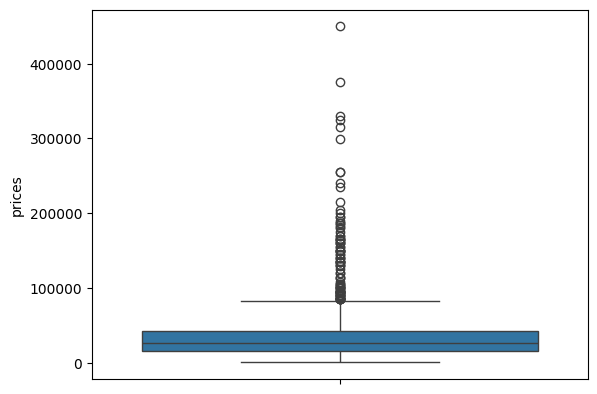

In [1219]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(df['prices'])

In [1220]:
df['rating'].dtype, df['rating'].min(), df['rating'].max()

(dtype('float64'), 50.0, 79.0)

<Axes: ylabel='rating'>

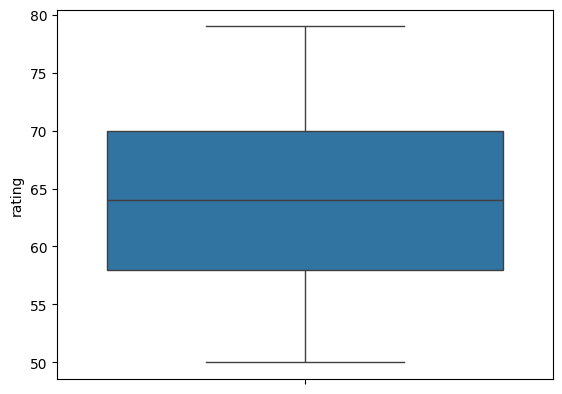

In [1221]:
sns.boxplot(df['rating'])

### **sim**

In [1222]:
print(df['has_5g'].value_counts())
print(df['has_nfc'].value_counts())
print(df['has_ir_blaster'].value_counts())

has_5g
True     774
False    241
Name: count, dtype: int64
has_nfc
False    606
True     409
Name: count, dtype: int64
has_ir_blaster
False    722
True     293
Name: count, dtype: int64


In [1223]:
df[df['has_5g'].isnull()]

,index,brand_name,model,prices,rating,sim,has_5g,has_nfc,has_ir_blaster,processor,processor_model,cpu_core_type,cpu_clock_speed_ghz,ram,ram_capacity,internal_memory,battery,battrey_capacity,fast_charging_watt,fast_charging_supported,display,display_size_inches,display_resolution_width_px,display_resolution_height_px,display_refresh_rate_hz,display_notch_type,camera,rear_camera,rear_camera_count,rear_cam_1,rear_cam_2,rear_cam_3,rear_cam_4,rear_cam_5,rear_camera_special_feature,front_camera,front_camers_count,front_camera_primary,front_camera_dual,memory_card_supported,memory_card_slot_type,memory_card_max_gb,card,os,operating_system
649,651,philips,Philips E2112S,1699,NaN,None,None,None,None,None,None,None,NaN,"32 MB RAM, 32 MB inbuilt",32.0,32.0,2500 mAh Battery,2500,NaN,False,2.2 inches Display,2.20,<NA>,<NA>,NaN,NaN,Main Rear Camera,Main Rear Camera,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,Yes,Dedicated,32.0,"Memory Card Supported, upto 32 GB",NaN,Not Specified
653,655,philips,Philips E2222,1999,NaN,None,None,None,None,None,None,None,NaN,"32 MB RAM, 32 MB inbuilt",32.0,32.0,1700 mAh Battery,1700,NaN,False,"2.44 inches, 160 x 283 px Display",2.44,160,283,NaN,NaN,Digital Camera Rear Camera,Digital Camera Rear Camera,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,Yes,Dedicated,32.0,"Memory Card Supported, upto 32 GB",NaN,Not Specified
857,859,philips,Philips E2101C,1028,NaN,None,None,None,None,None,None,None,NaN,"32 MB RAM, 32 MB inbuilt",32.0,32.0,1000 mAh Battery,1000,NaN,False,1.77 inches Display,1.77,<NA>,<NA>,NaN,NaN,No Rear Camera,No Rear Camera,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,Yes,Dedicated,32.0,"Memory Card Supported, upto 32 GB",NaN,Not Specified
944,946,philips,Philips E2221,1799,NaN,None,None,None,None,None,None,None,NaN,"32 MB RAM, 32 MB inbuilt",32.0,32.0,2500 mAh Battery,2500,NaN,False,2.44 inches Display,2.44,<NA>,<NA>,NaN,NaN,Digital Camera Rear Camera,Digital Camera Rear Camera,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,Yes,Dedicated,32.0,"Memory Card Supported, upto 32 GB",NaN,Not Specified
946,948,philips,Philips E2112,1168,NaN,None,None,None,None,None,None,None,NaN,"32 MB RAM, 32 MB inbuilt",32.0,32.0,2500 mAh Battery,2500,NaN,False,1.77 inches Display,1.77,<NA>,<NA>,NaN,NaN,Main Rear Camera,Main Rear Camera,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,Yes,Dedicated,32.0,"Memory Card Supported, upto 32 GB",NaN,Not Specified


### **Processor**

In [1224]:
print(df['processor_model'].value_counts())

processor_model
Dimensity 6300                            111
Snapdragon 6 Gen3                          20
Unisoc T7250                               20
Snapdragon 7s Gen4                         17
Snapdragon 7 Gen4                          16
Snapdragon 8 Gen5                          16
Unknown                                    16
Dimensity 7400                             14
Dimensity 6400                             13
Unisoc T8200                               13
Exynos 1330                                12
Snapdragon 8 Elite                         12
Dimensity 7400 Ultra                       12
Apple A20 Pro                              12
Snapdragon 8 Gen3                          11
Exynos 1380                                11
Snapdragon 4 Gen2                          11
Dimensity 7100                             11
Snapdragon 8s Gen3                         10
Snapdragon 7s Gen3                          9
Dimensity 7300 Energy                       9
Apple A19 Pro     

In [1225]:
print(df['cpu_core_type'].value_counts())

cpu_core_type
 Octa Core                778
 Octa Core Processor       32
 Hexa Core Processor       25
 Deca Core                 17
 Hexa Core                 14
Single Core                11
 Single Core                8
Single Core Processor       8
Dual Core Processor         3
 Dual Core                  2
 Single Core Processor      2
Dual Core                   2
 Nine-Cores                 1
 Nine Core                  1
 Nine Cores                 1
Octa Core Processor         1
6-core                      1
 Quad Core                  1
Name: count, dtype: int64


In [1226]:
df['cpu_core_type'] = df['cpu_core_type'].str.replace("Processor","").str.strip()
df['cpu_core_type'] = df['cpu_core_type'].str.replace("Nine-Cores","Nine Core").str.strip()
df['cpu_core_type'] = df['cpu_core_type'].str.replace("Nine Cores","Nine Core").str.strip()
df['cpu_core_type'] = df['cpu_core_type'].str.replace("6-core","Hexa Core").str.strip()

In [1227]:
df['cpu_core_type'].value_counts().sort_index()

,count
cpu_core_type,
Deca Core,17
Dual Core,7
Hexa Core,40
Nine Core,3
Octa Core,811
Quad Core,1
Single Core,29


In [1228]:
print(df['cpu_clock_speed_ghz'].value_counts())

cpu_clock_speed_ghz
2.40000    218
2.50000     75
2.20000     63
2.60000     61
2.30000     36
3.20000     31
1.80000     30
2.00000     29
2.80000     25
3.00000     24
2.70000     21
3.80000     19
0.00100     19
3.35000     17
2.84000     14
3.30000     14
3.40000     13
3.25000     12
4.47000     11
4.60000     10
4.74000      9
2.90000      8
3.10000      7
4.32000      6
3.78000      5
4.04000      5
2.63000      5
3.36000      5
0.00150      4
1.60000      4
1.00000      4
3.73000      4
2.85000      4
3.63000      3
4.21000      3
3.46000      3
2.96000      3
2.39000      3
0.00140      3
0.00120      3
0.00177      3
3.11000      2
0.00141      2
0.20800      2
3.84000      2
2.05000      2
0.00130      2
0.51200      2
2.36000      2
1.70000      2
0.25600      2
3.22000      1
4.05000      1
1.20000      1
3.39000      1
2.73000      1
0.10000      1
2.91000      1
0.22500      1
0.30800      1
1.40000      1
2.10000      1
Name: count, dtype: int64


In [1229]:
df['cpu_clock_speed_ghz'] = df['cpu_clock_speed_ghz'].round(3)

In [1230]:
df['cpu_clock_speed_ghz'].value_counts()

,count
cpu_clock_speed_ghz,
2.400,218
2.500,75
2.200,63
2.600,61
2.300,36
3.200,31
1.800,30
0.001,29
2.000,29


In [1231]:
core_map = {
    "Single Core": 1,
    "Dual Core": 2,
    "Triple Core": 3,
    "Quad Core": 4,
    "Penta Core": 5,
    "Hexa Core": 6,
    "Hepta Core": 7,
    "Octa Core": 8,
    "Nona Core": 9,
    "Nine Core": 9,
    "Deca Core": 10,
    "Undeca Core": 11,
    "Dodeca Core": 12
}

df['num_core'] = df['cpu_core_type'].map(core_map)

df['processor_brand'] = df['processor_model'].str.strip().str.split(" ").str.get(0)

In [1232]:
df['processor_brand'].value_counts()

,count
processor_brand,
Dimensity,340
Snapdragon,313
Unisoc,79
Exynos,63
Helio,41
Apple,28
Tensor,22
Unknown,16
Bionic,11


In [1233]:
df['processor_brand'].str.replace("UNISOC","Unisoc")

,processor_brand
0,Snapdragon
1,Snapdragon
2,Snapdragon
3,Apple
4,Snapdragon
5,Snapdragon
6,Apple
7,Snapdragon
8,Snapdragon
9,Dimensity


In [1234]:
processor_brand_map = {
    'Dimensity': 'MediaTek',
    'Helio': 'MediaTek',
    'MTK6739': 'MediaTek',

    'Snapdragon': 'Qualcomm',
    'Qualcomm': 'Qualcomm',
    'QC8905': 'Qualcomm',

    'Unisoc': 'Unisoc',
    'Spreadtrum': 'Unisoc',
    'Tiger': 'Unisoc',

    'Exynos': 'Samsung',
    'Tensor': 'Google',

    'Apple': 'Apple',
    'Bionic': 'Apple',

    'ARM': 'ARM',

    'ASR': 'ASR',

    'Unknown': 'Unknown'
}

df['processor_manufacturer'] = (df['processor_brand'].map(processor_brand_map))

In [1235]:
df['processor_manufacturer'].value_counts()

,count
processor_manufacturer,
MediaTek,383
Qualcomm,315
Unisoc,85
Samsung,63
Apple,39
Google,22
Unknown,16
ASR,1
ARM,1


### **Ram**

In [1236]:
df['ram'].value_counts()

,count
ram,
"8 GB RAM, 128 GB inbuilt",178
"8 GB RAM, 256 GB inbuilt",159
"6 GB RAM, 128 GB inbuilt",130
"12 GB RAM, 256 GB inbuilt",130
"4 GB RAM, 64 GB inbuilt",88
"4 GB RAM, 128 GB inbuilt",74
"32 MB RAM, 32 MB inbuilt",49
"12 GB RAM, 512 GB inbuilt",47
"4 MB RAM, 4 MB inbuilt",23


In [1237]:
df['ram_capacity'].value_counts()

,count
ram_capacity,
8.00,352
4.00,196
12.00,188
6.00,149
32.00,50
16.00,32
3.00,19
512.00,9
64.00,7


In [1238]:
df['internal_memory'].value_counts()

,count
internal_memory,
128.0,395
256.0,309
64.0,106
512.0,76
32.0,66
4.0,32
1.0,12
16.0,4
2.0,3


In [1239]:
df[df['internal_memory'].isnull()][['model','ram',	'ram_capacity',	'internal_memory']]

,model,ram,ram_capacity,internal_memory
533,Nokia 106 4G,4 MB RAM,4.0,NaN
562,Peace i17 Air,None,NaN,NaN
758,itel Power 450,None,NaN,NaN
803,Amaq Q1 4G,512 MB RAM,512.0,NaN
959,Lava Hero Shakti,None,NaN,NaN
1007,Micromax X072,None,NaN,NaN
1008,Lava ARC One,None,NaN,NaN


In [1240]:
# handle missing values

### **Battery**

In [1241]:
df[['battery', 'battrey_capacity', 'fast_charging_watt','fast_charging_supported']]

,battery,battrey_capacity,fast_charging_watt,fast_charging_supported
0,7000 mAh Battery with 68W Fast Charging,7000,68.00,True
1,10000 mAh Battery with 100W Fast Charging,10000,100.00,True
2,6000 mAh Battery with 45W Fast Charging,6000,45.00,True
3,4056 mAh Battery with Fast Charging,4056,NaN,True
4,6000 mAh Battery with 80W Fast Charging,6000,80.00,True
5,9000 mAh Battery with 67W Fast Charging,9000,67.00,True
6,3692 mAh Battery with Fast Charging,3692,NaN,True
7,7900 mAh Battery with 45W Fast Charging,7900,45.00,True
8,6800 mAh Battery with 80W Fast Charging,6800,80.00,True
9,7050 mAh Battery with 44W Fast Charging,7050,44.00,True


In [1242]:
df['fast_charging_watt'].value_counts()

,count
fast_charging_watt,
45.00,143
80.00,110
25.00,101
33.00,57
15.00,57
90.00,46
18.00,43
44.00,39
100.00,32


In [1243]:
# handle missing values

### **Display**

<Axes: xlabel='display_size_inches', ylabel='Density'>

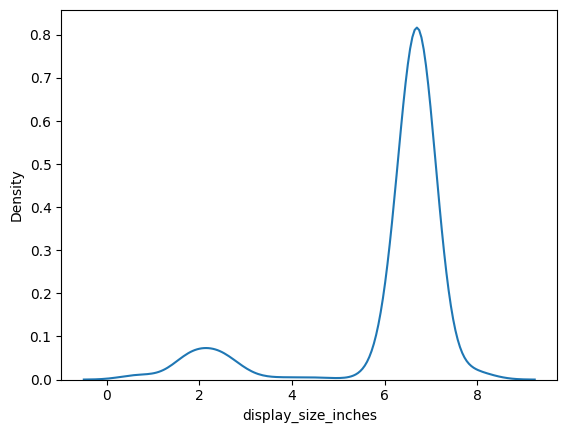

In [1244]:
sns.kdeplot(df['display_size_inches'])

<Axes: >

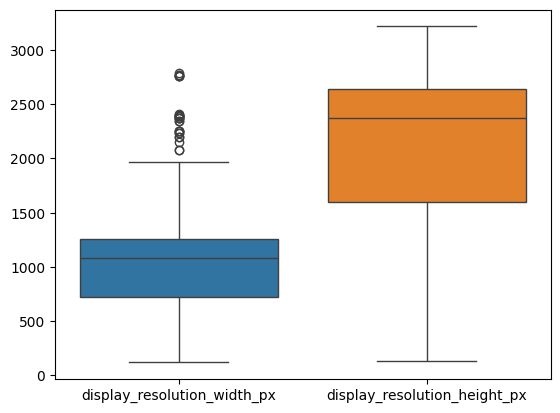

In [1245]:
sns.boxplot(data = df[['display_resolution_width_px','display_resolution_height_px']])

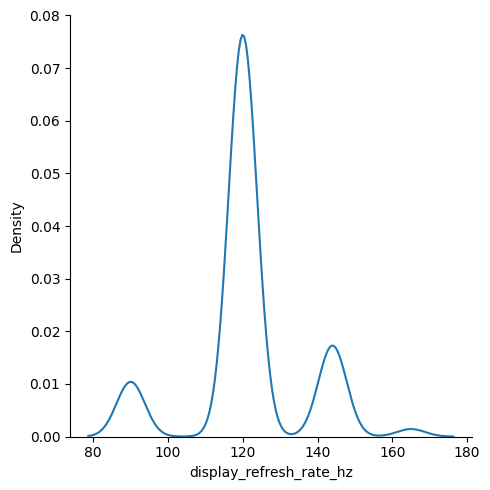

In [1246]:
sns.displot(kind = 'kde', data = df, x = 'display_refresh_rate_hz')

In [1247]:
df['display_notch_type'].value_counts()

,count
display_notch_type,
Punch Hole,682
Water Drop Notch,148
Dynamic Island,25
Small Notch,8
Dual Punch Hole,2
Large Notch,1


In [1248]:
# handle missing values

### **Camera**

In [1249]:
df.columns

Index(['index', 'brand_name', 'model', 'prices', 'rating', 'sim', 'has_5g',
       'has_nfc', 'has_ir_blaster', 'processor', 'processor_model',
       'cpu_core_type', 'cpu_clock_speed_ghz', 'ram', 'ram_capacity',
       'internal_memory', 'battery', 'battrey_capacity', 'fast_charging_watt',
       'fast_charging_supported', 'display', 'display_size_inches',
       'display_resolution_width_px', 'display_resolution_height_px',
       'display_refresh_rate_hz', 'display_notch_type', 'camera',
       'rear_camera', 'rear_camera_count', 'rear_cam_1', 'rear_cam_2',
       'rear_cam_3', 'rear_cam_4', 'rear_cam_5', 'rear_camera_special_feature',
       'front_camera', 'front_camers_count', 'front_camera_primary',
       'front_camera_dual', 'memory_card_supported', 'memory_card_slot_type',
       'memory_card_max_gb', 'card', 'os', 'operating_system', 'num_core',
       'processor_brand', 'processor_manufacturer'],
      dtype='object')

In [1250]:
# df[['camera',
#        'rear_camera', 'rear_camera_count', 'rear_cam_1', 'rear_cam_2',
#        'rear_cam_3', 'rear_cam_4', 'rear_cam_5', 'rear_camera_special_feature',
#        'front_camera', 'front_camers_count', 'front_camera_primary',
#        'front_camera_dual']]

In [1251]:
df['rear_camera_count'].value_counts()

,count
rear_camera_count,
2.0,420
3.0,339
1.0,197
0.0,33
4.0,27
5.0,1


In [1252]:
df['front_camers_count'].value_counts()

,count
front_camers_count,
1,994
2,26


In [1253]:
# handle missing values

### **Card**

In [1254]:
# df[['card','memory_card_supported', 'memory_card_slot_type','memory_card_max_gb']]

In [1255]:
df['memory_card_supported'].value_counts()

,count
memory_card_supported,
Yes,504
Unknown,286
No,230


In [1256]:
memory_card_supported_unknown_df = df[df['memory_card_supported'] == 'Unknown']
df.loc[memory_card_supported_unknown_df.index,'memory_card_supported'] = np.nan

In [1257]:
df['memory_card_supported'].value_counts()

,count
memory_card_supported,
Yes,504
No,230


In [1258]:
df['memory_card_slot_type'].value_counts()

,count
memory_card_slot_type,
Unknown,286
Hybrid,271
Dedicated,233
Not Supported,230


In [1259]:
memory_card_slot_type_unknown_df = df[df['memory_card_slot_type'] == 'Unknown']
df.loc[memory_card_slot_type_unknown_df.index,'memory_card_slot_type'] = np.nan

In [1260]:
df['memory_card_slot_type'].value_counts()

,count
memory_card_slot_type,
Hybrid,271
Dedicated,233
Not Supported,230


In [1261]:
df['memory_card_max_gb'].value_counts()

,count
memory_card_max_gb,
1024.0,170
2048.0,106
32.0,46
128.0,20
256.0,15
1536.0,7
512.0,6
8.0,5
64.0,4


### **os**

In [1262]:
df['os'].value_counts()

,count
os,
Android v16,295
Android v15,243
Android v14,100
Android v13,58
Android v12,56
Unknown,50
Android v11,35
Android v17,15
S30+,12


## extract Dataframe as a csv file

In [1263]:
# handle missing values
processor_manufacturer_unknown_df = df[df['processor_manufacturer'] == 'Unknown']
df.loc[processor_manufacturer_unknown_df.index,'processor_manufacturer'] = np.nan

# handle missing values
processor_brand_unknown_df = df[df['processor_brand'] == 'Unknown']
df.loc[processor_brand_unknown_df.index,'processor_brand'] = np.nan

processor_model
# handle missing values
processor_model_unknown_df = df[df['processor_model'] == 'Unknown']
df.loc[processor_model_unknown_df.index,'processor_model'] = np.nan

In [1264]:
df.columns

Index(['index', 'brand_name', 'model', 'prices', 'rating', 'sim', 'has_5g',
       'has_nfc', 'has_ir_blaster', 'processor', 'processor_model',
       'cpu_core_type', 'cpu_clock_speed_ghz', 'ram', 'ram_capacity',
       'internal_memory', 'battery', 'battrey_capacity', 'fast_charging_watt',
       'fast_charging_supported', 'display', 'display_size_inches',
       'display_resolution_width_px', 'display_resolution_height_px',
       'display_refresh_rate_hz', 'display_notch_type', 'camera',
       'rear_camera', 'rear_camera_count', 'rear_cam_1', 'rear_cam_2',
       'rear_cam_3', 'rear_cam_4', 'rear_cam_5', 'rear_camera_special_feature',
       'front_camera', 'front_camers_count', 'front_camera_primary',
       'front_camera_dual', 'memory_card_supported', 'memory_card_slot_type',
       'memory_card_max_gb', 'card', 'os', 'operating_system', 'num_core',
       'processor_brand', 'processor_manufacturer'],
      dtype='object')

In [1265]:
def unknown_to_nan(column):
  unknown_df = df[df[column] == 'Unknown']
  df.loc[unknown_df.index,column] = np.nan

columns = ['index', 'brand_name', 'model', 'prices', 'rating', 'sim', 'has_5g',
       'has_nfc', 'has_ir_blaster', 'processor', 'processor_model',
       'cpu_core_type', 'cpu_clock_speed_ghz', 'ram', 'ram_capacity',
       'internal_memory', 'battery', 'battrey_capacity', 'fast_charging_watt',
       'fast_charging_supported', 'display', 'display_size_inches',
       'display_resolution_width_px', 'display_resolution_height_px',
       'display_refresh_rate_hz', 'display_notch_type', 'camera',
       'rear_camera', 'rear_camera_count', 'rear_cam_1', 'rear_cam_2',
       'rear_cam_3', 'rear_cam_4', 'rear_cam_5', 'rear_camera_special_feature',
       'front_camera', 'front_camers_count', 'front_camera_primary',
       'front_camera_dual', 'memory_card_supported', 'memory_card_slot_type',
       'memory_card_max_gb', 'card', 'os', 'num_core', 'processor_brand',
       'processor_manufacturer']

for column in columns:
  unknown_to_nan(column)

In [1266]:
df['processor_model'].value_counts()

,count
processor_model,
Dimensity 6300,111
Snapdragon 6 Gen3,20
Unisoc T7250,20
Snapdragon 7s Gen4,17
Snapdragon 7 Gen4,16
Snapdragon 8 Gen5,16
Dimensity 7400,14
Dimensity 6400,13
Unisoc T8200,13


In [1267]:
df.to_csv("Mobile_dataset_cleaned_v1.csv",index=False)

### **Extract Uselfull columns for Further Analysis**

In [1268]:
df.columns

Index(['index', 'brand_name', 'model', 'prices', 'rating', 'sim', 'has_5g',
       'has_nfc', 'has_ir_blaster', 'processor', 'processor_model',
       'cpu_core_type', 'cpu_clock_speed_ghz', 'ram', 'ram_capacity',
       'internal_memory', 'battery', 'battrey_capacity', 'fast_charging_watt',
       'fast_charging_supported', 'display', 'display_size_inches',
       'display_resolution_width_px', 'display_resolution_height_px',
       'display_refresh_rate_hz', 'display_notch_type', 'camera',
       'rear_camera', 'rear_camera_count', 'rear_cam_1', 'rear_cam_2',
       'rear_cam_3', 'rear_cam_4', 'rear_cam_5', 'rear_camera_special_feature',
       'front_camera', 'front_camers_count', 'front_camera_primary',
       'front_camera_dual', 'memory_card_supported', 'memory_card_slot_type',
       'memory_card_max_gb', 'card', 'os', 'operating_system', 'num_core',
       'processor_brand', 'processor_manufacturer'],
      dtype='object')

In [1269]:
columns_name = ['brand_name', 'model', 'prices', 'rating','has_5g','has_nfc', 'has_ir_blaster',
                'processor_manufacturer','processor_brand','processor_model','cpu_core_type','num_core','cpu_clock_speed_ghz',
                'ram_capacity','internal_memory','battrey_capacity', 'fast_charging_watt','fast_charging_supported',
                'display_size_inches','display_resolution_width_px', 'display_resolution_height_px','display_refresh_rate_hz', 'display_notch_type',
                'rear_camera_count', 'rear_cam_1','front_camers_count', 'front_camera_primary',
                'memory_card_supported', 'memory_card_slot_type','memory_card_max_gb', 'operating_system']
final_df = df[columns_name]

In [1270]:
final_df.head()

,brand_name,model,prices,rating,has_5g,has_nfc,has_ir_blaster,processor_manufacturer,processor_brand,processor_model,cpu_core_type,num_core,cpu_clock_speed_ghz,ram_capacity,internal_memory,battrey_capacity,fast_charging_watt,fast_charging_supported,display_size_inches,display_resolution_width_px,display_resolution_height_px,display_refresh_rate_hz,display_notch_type,rear_camera_count,rear_cam_1,front_camers_count,front_camera_primary,memory_card_supported,memory_card_slot_type,memory_card_max_gb,operating_system
0,motorola,Motorola Edge 70 Fusion,27589,70.0,True,True,False,Qualcomm,Snapdragon,Snapdragon 7s Gen4,Octa Core,8.0,2.7,8.0,128.0,7000,68.0,True,6.80,1272,2772,144.0,Punch Hole,3.0,50,1,32,NaN,NaN,NaN,Android
1,xiaomi,Xiaomi Redmi Note 17 Pro Max,49999,NaN,True,True,True,Qualcomm,Snapdragon,Snapdragon 6 Gen5,Octa Core,8.0,2.6,8.0,256.0,10000,100.0,True,6.83,1280,2772,120.0,Punch Hole,2.0,50,1,32,NaN,NaN,NaN,Android
2,realme,Realme P3 5G,15999,61.0,True,True,False,Qualcomm,Snapdragon,Snapdragon 6 Gen4,Octa Core,8.0,2.3,6.0,128.0,6000,45.0,True,6.67,1080,2400,120.0,Punch Hole,2.0,50,1,16,NaN,NaN,NaN,Android
3,apple,Apple iPhone 18 Pro,164900,NaN,True,True,False,Apple,Apple,Apple A20 Pro,Hexa Core,6.0,NaN,12.0,256.0,4056,NaN,True,6.30,1206,2622,120.0,Dynamic Island,3.0,48,1,18,No,Not Supported,NaN,iOS
4,realme,Realme P3 Pro 5G (12GB RAM +256GB),23999,66.0,True,False,False,Qualcomm,Snapdragon,Snapdragon 7s Gen3,Octa Core,8.0,2.5,12.0,256.0,6000,80.0,True,6.83,1272,2800,120.0,Punch Hole,2.0,50,1,16,NaN,NaN,NaN,Android


In [1277]:
final_df.to_csv("Mobile_dataset_cleaned_v2.csv",index=False)

In [1272]:
final_df

,brand_name,model,prices,rating,has_5g,has_nfc,has_ir_blaster,processor_manufacturer,processor_brand,processor_model,cpu_core_type,num_core,cpu_clock_speed_ghz,ram_capacity,internal_memory,battrey_capacity,fast_charging_watt,fast_charging_supported,display_size_inches,display_resolution_width_px,display_resolution_height_px,display_refresh_rate_hz,display_notch_type,rear_camera_count,rear_cam_1,front_camers_count,front_camera_primary,memory_card_supported,memory_card_slot_type,memory_card_max_gb,operating_system
0,motorola,Motorola Edge 70 Fusion,27589,70.0,True,True,False,Qualcomm,Snapdragon,Snapdragon 7s Gen4,Octa Core,8.0,2.700,8.00,128.0,7000,68.00,True,6.80,1272,2772,144.0,Punch Hole,3.0,50,1,32,NaN,NaN,NaN,Android
1,xiaomi,Xiaomi Redmi Note 17 Pro Max,49999,NaN,True,True,True,Qualcomm,Snapdragon,Snapdragon 6 Gen5,Octa Core,8.0,2.600,8.00,256.0,10000,100.00,True,6.83,1280,2772,120.0,Punch Hole,2.0,50,1,32,NaN,NaN,NaN,Android
2,realme,Realme P3 5G,15999,61.0,True,True,False,Qualcomm,Snapdragon,Snapdragon 6 Gen4,Octa Core,8.0,2.300,6.00,128.0,6000,45.00,True,6.67,1080,2400,120.0,Punch Hole,2.0,50,1,16,NaN,NaN,NaN,Android
3,apple,Apple iPhone 18 Pro,164900,NaN,True,True,False,Apple,Apple,Apple A20 Pro,Hexa Core,6.0,NaN,12.00,256.0,4056,NaN,True,6.30,1206,2622,120.0,Dynamic Island,3.0,48,1,18,No,Not Supported,NaN,iOS
4,realme,Realme P3 Pro 5G (12GB RAM +256GB),23999,66.0,True,False,False,Qualcomm,Snapdragon,Snapdragon 7s Gen3,Octa Core,8.0,2.500,12.00,256.0,6000,80.00,True,6.83,1272,2800,120.0,Punch Hole,2.0,50,1,16,NaN,NaN,NaN,Android
5,xiaomi,Xiaomi Redmi Note 17 Pro,36999,71.0,True,True,True,Qualcomm,Snapdragon,Snapdragon 6s Gen4,Octa Core,8.0,2.400,6.00,128.0,9000,67.00,True,6.83,1280,2772,120.0,Punch Hole,2.0,50,1,16,NaN,NaN,NaN,Android
6,apple,Apple iPhone 17,82900,76.0,True,True,False,Apple,Apple,Apple A19,Hexa Core,6.0,NaN,8.00,256.0,3692,NaN,True,6.30,1206,2622,120.0,Small Notch,2.0,48,1,18,No,Not Supported,NaN,iOS
7,xiaomi,Xiaomi Redmi 17 5G,23999,61.0,True,True,True,Qualcomm,Snapdragon,Snapdragon 4 Gen5,Octa Core,8.0,2.400,6.00,128.0,7900,45.00,True,6.90,720,1600,120.0,Punch Hole,2.0,50,1,8,Yes,Hybrid,2048.0,Android
8,oneplus,OnePlus Nord 5 5G,31999,75.0,True,True,True,Qualcomm,Snapdragon,Snapdragon 8s Gen3,Octa Core,8.0,3.000,8.00,256.0,6800,80.00,True,6.83,1272,2800,144.0,Punch Hole,2.0,50,1,50,NaN,NaN,NaN,Android
9,vivo,Vivo T5 5G,34999,71.0,True,False,True,MediaTek,Dimensity,Dimensity 7500 Turbo,Octa Core,8.0,2.600,6.00,128.0,7050,44.00,True,6.83,1260,2800,144.0,Punch Hole,2.0,50,1,32,No,Not Supported,NaN,Android


In [1273]:
final_df['operating_system'].value_counts()

,count
operating_system,
Android,836
Not Specified,120
iOS,36
S30+ / Feature OS,13
Symbian,10
Nucleus,2
RTOS,2
Mocor,1


In [1274]:
df[df['operating_system']=='Not Specified'][['model','os', 'operating_system']]

,model,os,operating_system
22,Apple iPhone Duo,None,Not Specified
74,Apple iPhone Duo (2TB),None,Not Specified
153,Apple iPhone Duo (1TB),None,Not Specified
190,Samsung Galaxy Z Flip 3,None,Not Specified
201,Nokia 210 4G (2026),NaN,Not Specified
352,Apple iPhone Duo (512GB),None,Not Specified
369,Nokia 123 Shield,None,Not Specified
383,Peace SC26 4G,NaN,Not Specified
387,Motorola Razr Fold,None,Not Specified
388,Motorola Moto A300 2026,None,Not Specified


In [1275]:
df[df['operating_system']=='Other'][['model','os', 'operating_system']]

,model,os,operating_system


In [1276]:
df['operating_system'].isna().sum()

np.int64(0)